# 🚗 Cars24 — Exploratory Data Analysis (EDA)
### Project: Used Car Price Prediction | Cars24 Platform
---
> **Author:** [Siddarth sharma]  
> **Date:** 2026 April  
> **Dataset:** cars24_data.csv  
> **Target Variable:** `price` (Resale Price in ₹)

---

## 📋 Table of Contents
1. [Environment Setup & Imports](#1)
2. [Data Loading & Initial Inspection](#2)
3. [Data Quality Assessment](#3)
4. [Data Cleaning & Preprocessing](#4)
5. [Feature Engineering](#5)
6. [Univariate Analysis — Numerical Features](#6)
7. [Univariate Analysis — Categorical Features](#7)
8. [Bivariate Analysis — Feature vs Price](#8)
9. [Multivariate Analysis & Correlation Heatmap](#9)
10. [Outlier Detection & Treatment](#10)
11. [Key Business Insights & Conclusions](#11)


---
<a id='1'></a>
## 1. Environment Setup & Imports


In [1]:
# ── Standard Libraries ──────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Display Settings ─────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams.update({
    'figure.dpi'       : 120,
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#F8F9FA',
    'axes.grid'        : True,
    'grid.alpha'       : 0.4,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

PALETTE   = 'Set2'
PRIMARY   = '#2196F3'
SECONDARY = '#FF5722'
ACCENT    = '#4CAF50'

print("✅  All libraries imported successfully.")
print(f"    pandas  : {pd.__version__}")
print(f"    numpy   : {np.__version__}")
print(f"    seaborn : {sns.__version__}")


✅  All libraries imported successfully.
    pandas  : 2.2.2
    numpy   : 1.26.4
    seaborn : 0.13.2


---
<a id='2'></a>
## 2. Data Loading & Initial Inspection


In [2]:
# ── Load Dataset ──────────────────────────────────────────────────────────
df = pd.read_csv('cars24_data.csv')

print("=" * 60)
print("         DATASET OVERVIEW")
print("=" * 60)
print(f"  Total Records (Rows)  : {df.shape[0]:,}")
print(f"  Total Features (Cols) : {df.shape[1]}")
print(f"  Memory Usage          : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print("=" * 60)


         DATASET OVERVIEW
  Total Records (Rows)  : 6,437
  Total Features (Cols) : 19
  Memory Usage          : 5059.1 KB


In [3]:
# ── First 5 Rows ──────────────────────────────────────────────────────────
print("── First 5 Records ──")
df.head()


── First 5 Records ──


,name,make,model,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,storename,isc24assured,registrationcity,registrationstate,benefits,discountprice,price,url,createdDate
0,Hyundai Elite i20,Hyundai,Elite I20,Kochi,2017,Petrol,35939,2,Manual,Hatchback,Kochi-Pns,False,Kozhikode,Kerala,13898,47399,607000,https://www.cars24.com/buy-used-hyundai-elite-...,24-03-2022
1,Maruti Alto 800,Maruti,Alto 800,Mumbai,2016,Petrol + Cng,6180,1,Manual,Hatchback,Hi-West Mumbai,False,Mumbai,Maharashtra,12542,2099,326000,https://www.cars24.com/buy-used-maruti-alto-80...,09-11-2022
2,Maruti Dzire,Maruti,Dzire,Lucknow,2019,Petrol + Cng,46808,1,Manual,Sedan,Vibhuti Khand - Gomti Nagar,False,Lucknow,Uttar Pradesh,13898,26000,640000,https://www.cars24.com/buy-used-maruti-dzire-2...,30-09-2022
3,KIA SELTOS,Kia,Seltos,Bangalore,2020,Diesel,26045,1,Manual,SUV,Bengaluru-Pns,False,Bengaluru,Karnataka,9688,143700,1354000,https://www.cars24.com/buy-used-kia-seltos-202...,04-07-2022
4,Maruti Ertiga,Maruti,Ertiga,Kolkata,2017,Petrol,53056,1,Manual,SUV,Hi-Kolkata,False,Barrackpore,West Bengal,13898,22800,676000,https://www.cars24.com/buy-used-maruti-ertiga-...,28-10-2022


In [4]:
# ── Data Types & Non-Null Counts ─────────────────────────────────────────
print("── Column Info ──")
df.info()


── Column Info ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6437 entries, 0 to 6436
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   name               6437 non-null   object
 1   make               6437 non-null   object
 2   model              6437 non-null   object
 3   city               6437 non-null   object
 4   year               6437 non-null   int64 
 5   fueltype           6437 non-null   object
 6   kilometerdriven    6437 non-null   int64 
 7   ownernumber        6437 non-null   int64 
 8   transmission       6061 non-null   object
 9   bodytype           6062 non-null   object
 10  storename          6437 non-null   object
 11  isc24assured       6437 non-null   bool  
 12  registrationcity   6437 non-null   object
 13  registrationstate  6437 non-null   object
 14  benefits           6437 non-null   int64 
 15  discountprice      6437 non-null   int64 
 16  price              6437 

In [5]:
# ── Statistical Summary — Numerical Features ────────────────────────────
print("── Statistical Summary (Numerical) ──")
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','50%','max'])


── Statistical Summary (Numerical) ──


,count,mean,std,min,25%,50%,75%,max
year,6437.000000,2017.636166,2.656825,2008.000000,2016.000000,2018.000000,2020.000000,2022.000000
kilometerdriven,6437.000000,41568.066335,26187.115364,64.000000,20580.000000,38177.000000,59333.000000,455601.000000
ownernumber,6437.000000,1.235669,0.454501,1.000000,1.000000,1.000000,1.000000,3.000000
benefits,6437.000000,12079.200559,2458.162316,9688.000000,9688.000000,12542.000000,13898.000000,19407.000000
discountprice,6437.000000,23500.592512,41579.296564,-155500.000000,-100.000000,10600.000000,37000.000000,388300.000000
price,6437.000000,678137.759360,345039.484137,134000.000000,439000.000000,588000.000000,829000.000000,3048000.000000


---
<a id='3'></a>
## 3. Data Quality Assessment


In [6]:
# ── Missing Value Analysis ───────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %'     : missing_pct,
    'Data Type'     : df.dtypes
}).sort_values('Missing %', ascending=False)

print("── Missing Value Report ──")
print(missing_df[missing_df['Missing Count'] > 0].to_string())
print()
print(f"✅ Columns with NO missing values : {(missing == 0).sum()}")
print(f"⚠️  Columns WITH missing values   : {(missing > 0).sum()}")


── Missing Value Report ──
              Missing Count  Missing % Data Type
transmission            376       5.84    object
bodytype                375       5.83    object

✅ Columns with NO missing values : 17
⚠️  Columns WITH missing values   : 2


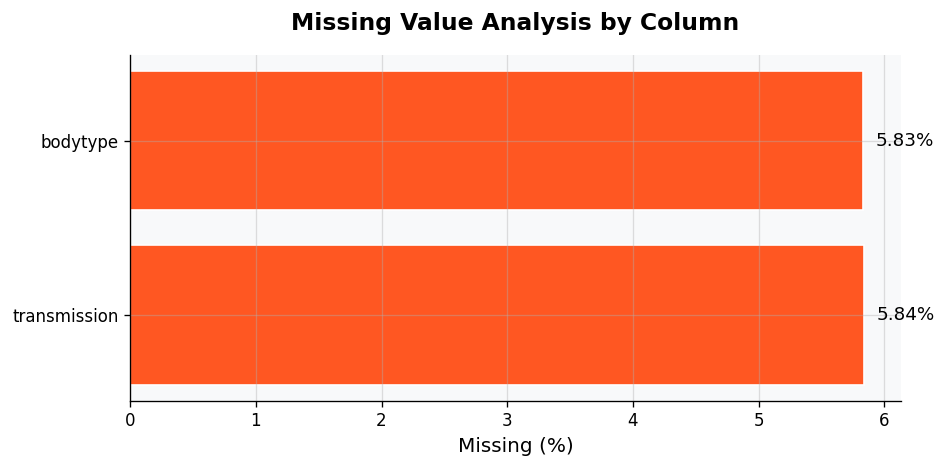

In [7]:
# ── Visualise Missing Values ─────────────────────────────────────────────
cols_with_missing = missing_df[missing_df['Missing Count'] > 0].index.tolist()

if cols_with_missing:
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(cols_with_missing,
                   missing_df.loc[cols_with_missing, 'Missing %'],
                   color=SECONDARY, edgecolor='white')
    for bar, val in zip(bars, missing_df.loc[cols_with_missing, 'Missing %']):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}%', va='center', fontsize=11)
    ax.set_xlabel('Missing (%)', fontsize=12)
    ax.set_title('Missing Value Analysis by Column', fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()
else:
    print("✅ No missing values found in the dataset.")


In [8]:
# ── Duplicate Check ──────────────────────────────────────────────────────
dupes = df.duplicated().sum()
print(f"Duplicate Rows : {dupes}")
print(f"Unique URLs    : {df['url'].nunique()} / {len(df)} total rows")


Duplicate Rows : 15
Unique URLs    : 6422 / 6437 total rows


---
<a id='4'></a>
## 4. Data Cleaning & Preprocessing

**Steps performed:**
- Drop irrelevant columns (`url`, `storename`, `name`)
- Standardise `bodytype` inconsistencies (`SEDAN` → `Sedan`)
- Convert `createdDate` to datetime
- Fill missing `transmission` and `bodytype` with mode


In [9]:
# ── Step 1: Drop irrelevant / high-cardinality columns ──────────────────
df_clean = df.drop(columns=['url', 'storename', 'name', 'registrationcity'])

print(f"Shape before cleaning : {df.shape}")
print(f"Shape after drop      : {df_clean.shape}")


Shape before cleaning : (6437, 19)
Shape after drop      : (6437, 15)


In [10]:
# ── Step 2: Standardise bodytype ─────────────────────────────────────────
df_clean['bodytype'] = df_clean['bodytype'].str.strip().str.title()
print("Body type value counts after standardisation:")
print(df_clean['bodytype'].value_counts())


Body type value counts after standardisation:
bodytype
Hatchback       3588
Suv             1312
Sedan           1050
Luxury Suv        58
Luxury Sedan      54
Name: count, dtype: int64


In [11]:
# ── Step 3: Parse createdDate ─────────────────────────────────────────────
df_clean['createdDate'] = pd.to_datetime(df_clean['createdDate'], dayfirst=True, errors='coerce')
df_clean['listing_month'] = df_clean['createdDate'].dt.month
df_clean['listing_year']  = df_clean['createdDate'].dt.year
print("Date parsing done. Sample:")
print(df_clean[['createdDate','listing_month','listing_year']].head(3))


Date parsing done. Sample:
  createdDate  listing_month  listing_year
0  2022-03-24              3          2022
1  2022-11-09             11          2022
2  2022-09-30              9          2022


In [12]:
# ── Step 4: Fill missing Transmission & Bodytype with mode ──────────────
for col in ['transmission', 'bodytype']:
    mode_val = df_clean[col].mode()[0]
    df_clean[col].fillna(mode_val, inplace=True)
    print(f"  '{col}' — filled {df[col].isnull().sum()} NaN(s) with mode: '{mode_val}'")

print(f"\nMissing values remaining : {df_clean.isnull().sum().sum()}")


  'transmission' — filled 376 NaN(s) with mode: 'Manual'
  'bodytype' — filled 375 NaN(s) with mode: 'Hatchback'

Missing values remaining : 0


---
<a id='5'></a>
## 5. Feature Engineering

> **This step distinguishes a good EDA from a great one.**  
> New features improve model signal and uncover hidden patterns.


In [13]:
# ── New Features ─────────────────────────────────────────────────────────
CURRENT_YEAR = 2024

# 1. Car Age
df_clean['car_age'] = CURRENT_YEAR - df_clean['year']

# 2. Price per KM (value-for-money metric)
df_clean['price_per_km'] = (df_clean['price'] / df_clean['kilometerdriven']).round(2)

# 3. Brand Tier (luxury vs premium vs economy)
luxury_brands  = ['Audi','Bmw','Mercedes Benz','Jaguar','Porsche','Volvo','Land Rover']
premium_brands = ['Mg','Jeep','Kia','Skoda','Volkswagen','Toyota']

def brand_tier(make):
    if make in luxury_brands:  return 'Luxury'
    if make in premium_brands: return 'Premium'
    return 'Economy'

df_clean['brand_tier'] = df_clean['make'].apply(brand_tier)

# 4. High Mileage flag (> 75th percentile)
q75 = df_clean['kilometerdriven'].quantile(0.75)
df_clean['high_mileage'] = (df_clean['kilometerdriven'] > q75).astype(int)

print("── New Features Added ──")
print(df_clean[['car_age','price_per_km','brand_tier','high_mileage']].head(5))
print(f"\nBrand Tier Distribution:")
print(df_clean['brand_tier'].value_counts())


── New Features Added ──
   car_age  price_per_km brand_tier  high_mileage
0        7         16.89    Economy             0
1        8         52.75    Economy             0
2        5         13.67    Economy             0
3        4         51.99    Premium             0
4        7         12.74    Economy             0

Brand Tier Distribution:
brand_tier
Economy    5867
Premium     560
Luxury       10
Name: count, dtype: int64


---
<a id='6'></a>
## 6. Univariate Analysis — Numerical Features

> Understand each numerical variable in isolation: its distribution, central tendency, spread, and skewness.


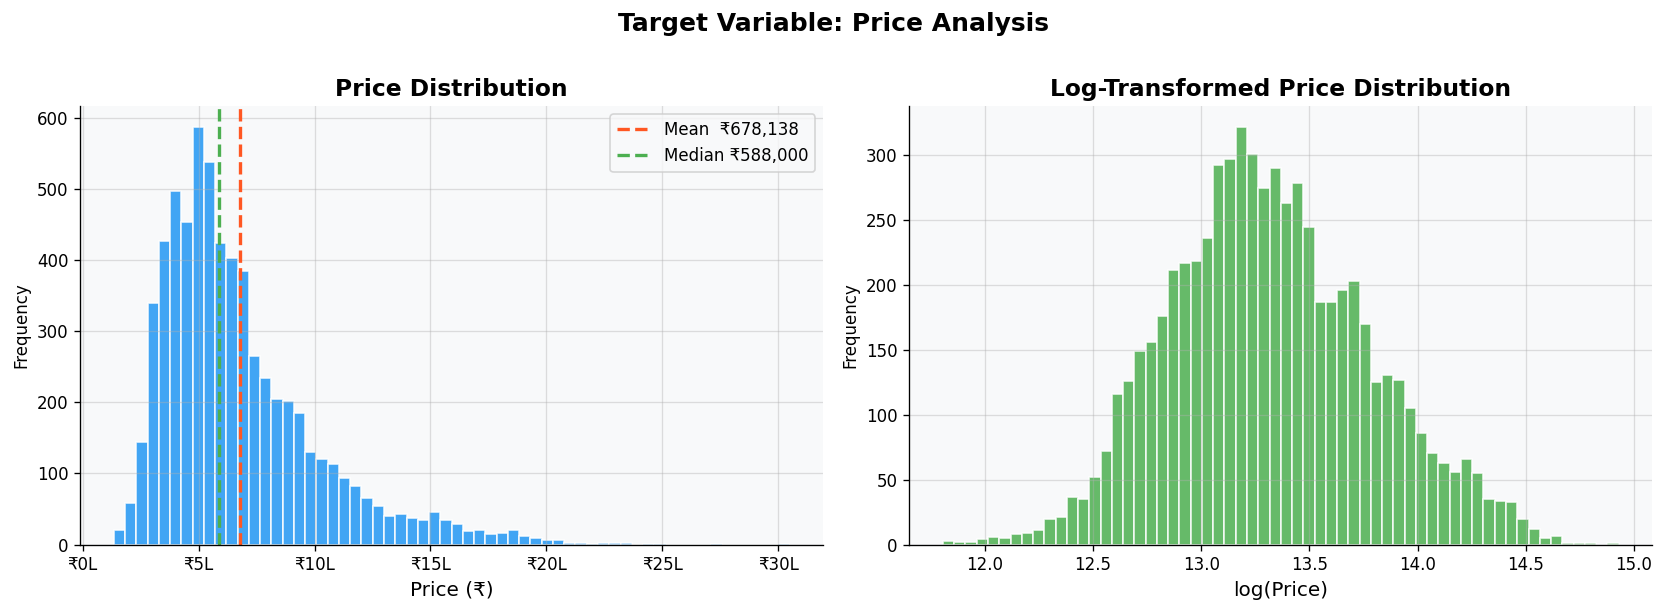

Skewness of Price : 1.522  (Right-skewed ⚠️)
Mean   : ₹   678,138
Median : ₹   588,000
Std    : ₹   345,039


In [14]:
# ── Price Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean['price'], bins=60, color=PRIMARY, edgecolor='white', alpha=0.85)
axes[0].axvline(df_clean['price'].mean(),   color=SECONDARY, ls='--', lw=2, label=f'Mean  ₹{df_clean["price"].mean():,.0f}')
axes[0].axvline(df_clean['price'].median(), color=ACCENT,    ls='--', lw=2, label=f'Median ₹{df_clean["price"].median():,.0f}')
axes[0].set_title('Price Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price (₹)', fontsize=12)
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
axes[0].legend()

# Log-transformed (to handle skew)
log_prices = np.log1p(df_clean['price'])
axes[1].hist(log_prices, bins=60, color=ACCENT, edgecolor='white', alpha=0.85)
axes[1].set_title('Log-Transformed Price Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(Price)', fontsize=12)
axes[1].set_ylabel('Frequency')

plt.suptitle('Target Variable: Price Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

skewness = df_clean['price'].skew()
print(f"Skewness of Price : {skewness:.3f}  ({'Right-skewed ⚠️' if skewness > 1 else 'Approximately Normal ✅'})")
print(f"Mean   : ₹{df_clean['price'].mean():>10,.0f}")
print(f"Median : ₹{df_clean['price'].median():>10,.0f}")
print(f"Std    : ₹{df_clean['price'].std():>10,.0f}")


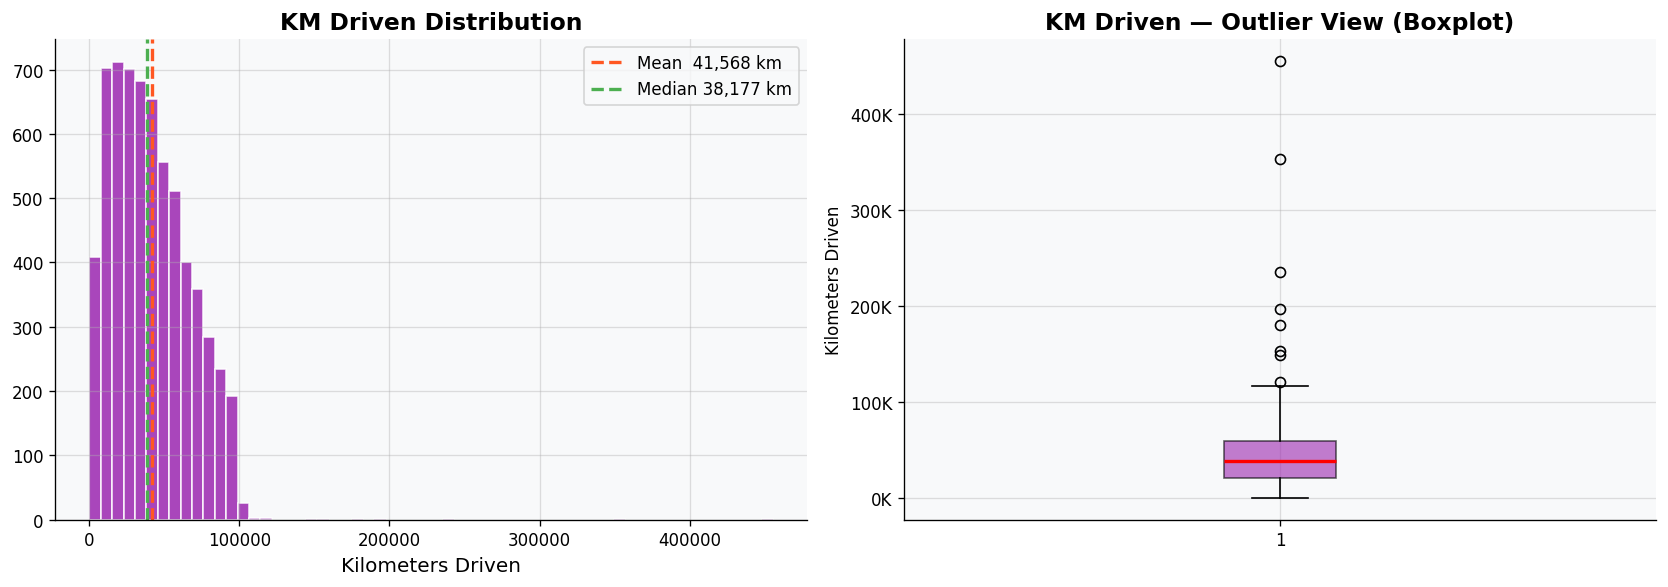

KM Driven Statistics:
count      6,437
mean      41,568
std       26,187
min           64
25%       20,580
50%       38,177
75%       59,333
max      455,601
Name: kilometerdriven, dtype: object


In [15]:
# ── KM Driven Distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['kilometerdriven'], bins=60, color='#9C27B0', edgecolor='white', alpha=0.85)
axes[0].axvline(df_clean['kilometerdriven'].mean(),   color=SECONDARY, ls='--', lw=2,
                label=f'Mean  {df_clean["kilometerdriven"].mean():,.0f} km')
axes[0].axvline(df_clean['kilometerdriven'].median(), color=ACCENT,    ls='--', lw=2,
                label=f'Median {df_clean["kilometerdriven"].median():,.0f} km')
axes[0].set_title('KM Driven Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kilometers Driven', fontsize=12)
axes[0].legend()

# Boxplot
axes[1].boxplot(df_clean['kilometerdriven'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#9C27B0', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('KM Driven — Outlier View (Boxplot)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Kilometers Driven')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.show()

print(f"KM Driven Statistics:")
print(df_clean['kilometerdriven'].describe().apply(lambda x: f'{x:,.0f}'))


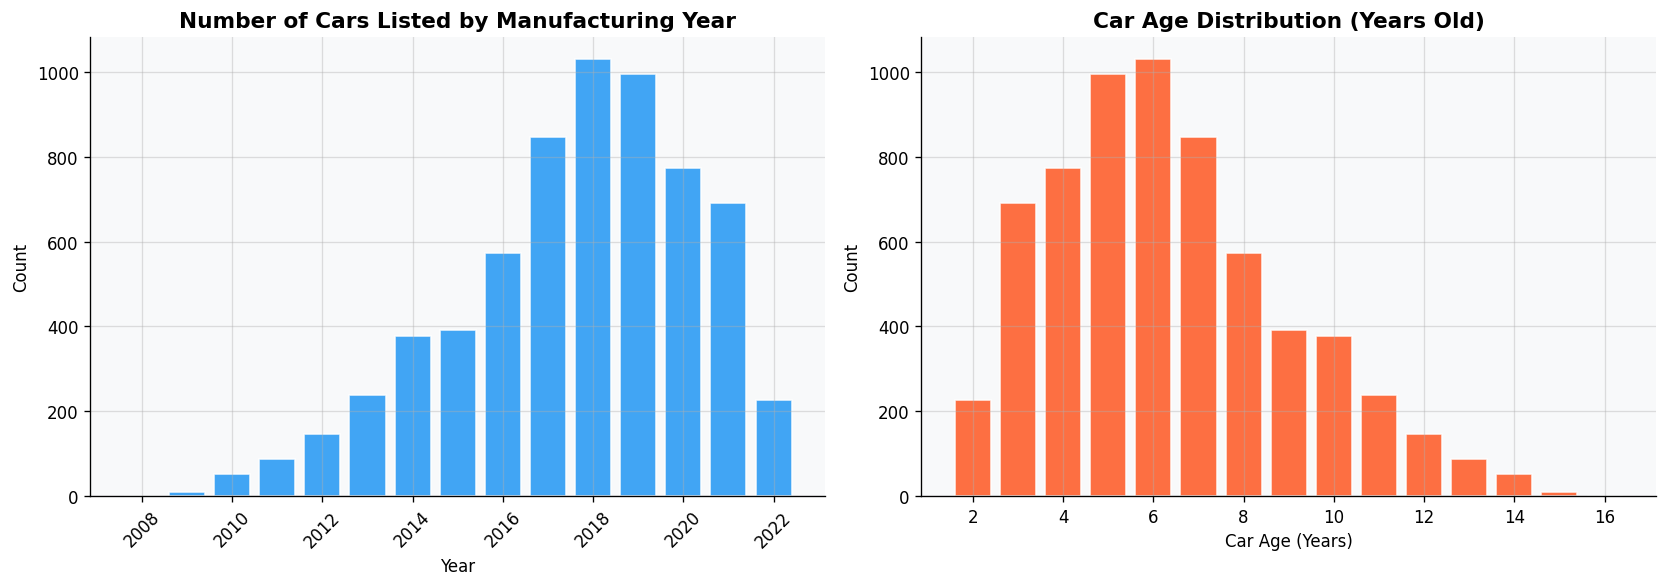

Most common manufacturing years (top 5):
year
2018    1031
2019     996
2017     846
2020     774
2021     690


In [16]:
# ── Year & Car Age Distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

year_counts = df_clean['year'].value_counts().sort_index()
axes[0].bar(year_counts.index, year_counts.values, color=PRIMARY, edgecolor='white', alpha=0.85)
axes[0].set_title('Number of Cars Listed by Manufacturing Year', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

age_counts = df_clean['car_age'].value_counts().sort_index()
axes[1].bar(age_counts.index, age_counts.values, color=SECONDARY, edgecolor='white', alpha=0.85)
axes[1].set_title('Car Age Distribution (Years Old)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Car Age (Years)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Most common manufacturing years (top 5):")
print(year_counts.sort_values(ascending=False).head(5).to_string())


---
<a id='7'></a>
## 7. Univariate Analysis — Categorical Features


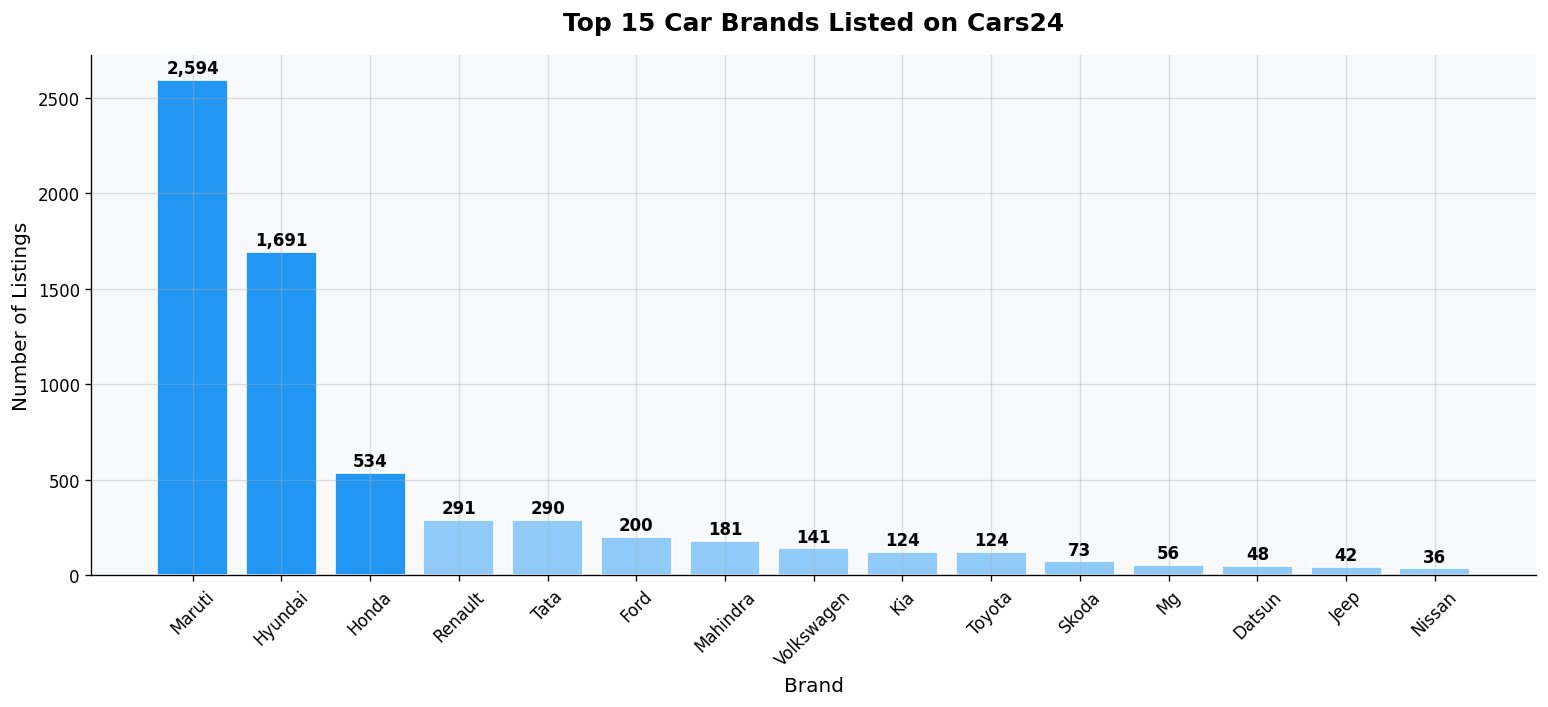

📊 Maruti + Hyundai account for 66.6% of all listings — heavily budget-segment dominated.


In [17]:
# ── Brand (Make) Distribution ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

brand_counts = df_clean['make'].value_counts().head(15)
colors = [PRIMARY if i < 3 else '#90CAF9' for i in range(len(brand_counts))]
bars = ax.bar(brand_counts.index, brand_counts.values, color=colors, edgecolor='white')

for bar, val in zip(bars, brand_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Top 15 Car Brands Listed on Cars24', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Brand', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

top2 = brand_counts.head(2)
pct  = (top2.sum() / len(df_clean) * 100).round(1)
print(f"📊 Maruti + Hyundai account for {pct}% of all listings — heavily budget-segment dominated.")


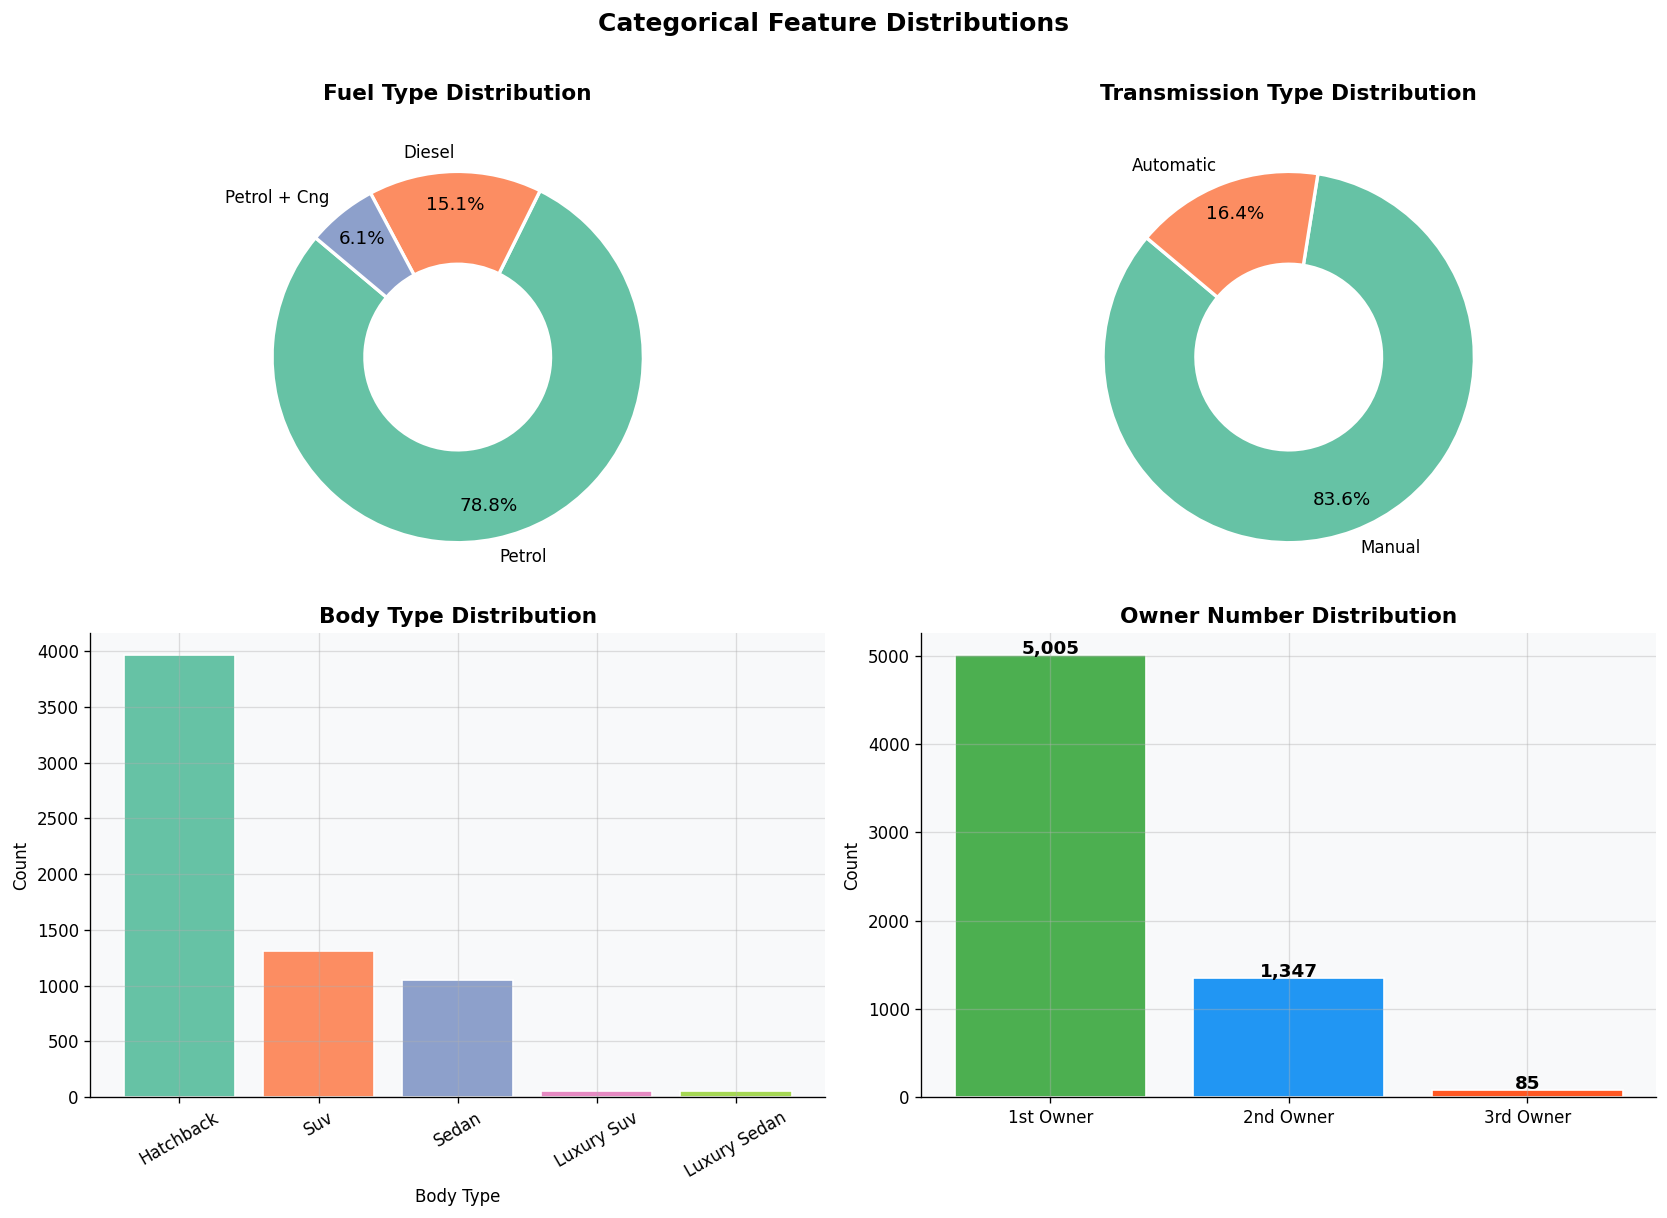

In [18]:
# ── Fuel Type / Transmission / Body Type / Owner Number ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def pie_plot(ax, col, title):
    counts = df_clean[col].value_counts()
    wedges, texts, autotexts = ax.pie(
        counts, labels=counts.index, autopct='%1.1f%%',
        startangle=140, pctdistance=0.82,
        colors=sns.color_palette(PALETTE, len(counts)),
        wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2))
    for t in autotexts: t.set_fontsize(11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)

pie_plot(axes[0,0], 'fueltype',     'Fuel Type Distribution')
pie_plot(axes[0,1], 'transmission', 'Transmission Type Distribution')

# Body type bar
bt = df_clean['bodytype'].value_counts()
axes[1,0].bar(bt.index, bt.values, color=sns.color_palette(PALETTE, len(bt)), edgecolor='white')
axes[1,0].set_title('Body Type Distribution', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Body Type')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=30)

# Owner number
on = df_clean['ownernumber'].value_counts().sort_index()
owner_labels = {1:'1st Owner', 2:'2nd Owner', 3:'3rd Owner'}
axes[1,1].bar([owner_labels.get(x, str(x)) for x in on.index], on.values,
              color=[ACCENT, PRIMARY, SECONDARY], edgecolor='white')
for i, (bar, val) in enumerate(zip(axes[1,1].patches, on.values)):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                   f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[1,1].set_title('Owner Number Distribution', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Count')

plt.suptitle('Categorical Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


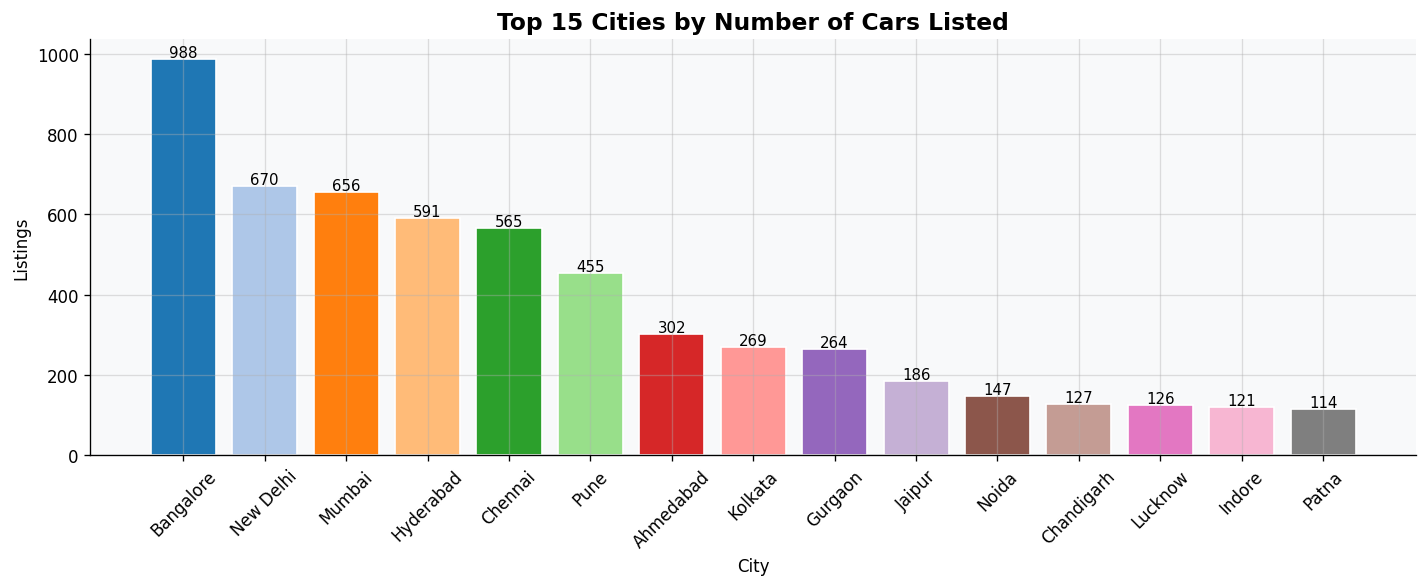

Top city: Bangalore with 988 listings (15.3%)


In [19]:
# ── City-wise Listing Distribution ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
city_counts = df_clean['city'].value_counts().head(15)
ax.bar(city_counts.index, city_counts.values,
       color=sns.color_palette('tab20', len(city_counts)), edgecolor='white')
ax.set_title('Top 15 Cities by Number of Cars Listed', fontsize=14, fontweight='bold')
ax.set_xlabel('City')
ax.set_ylabel('Listings')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(ax.patches, city_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontsize=9)
plt.tight_layout()
plt.show()
print(f"Top city: {city_counts.index[0]} with {city_counts.iloc[0]:,} listings ({city_counts.iloc[0]/len(df_clean)*100:.1f}%)")


---
<a id='8'></a>
## 8. Bivariate Analysis — Feature vs Price




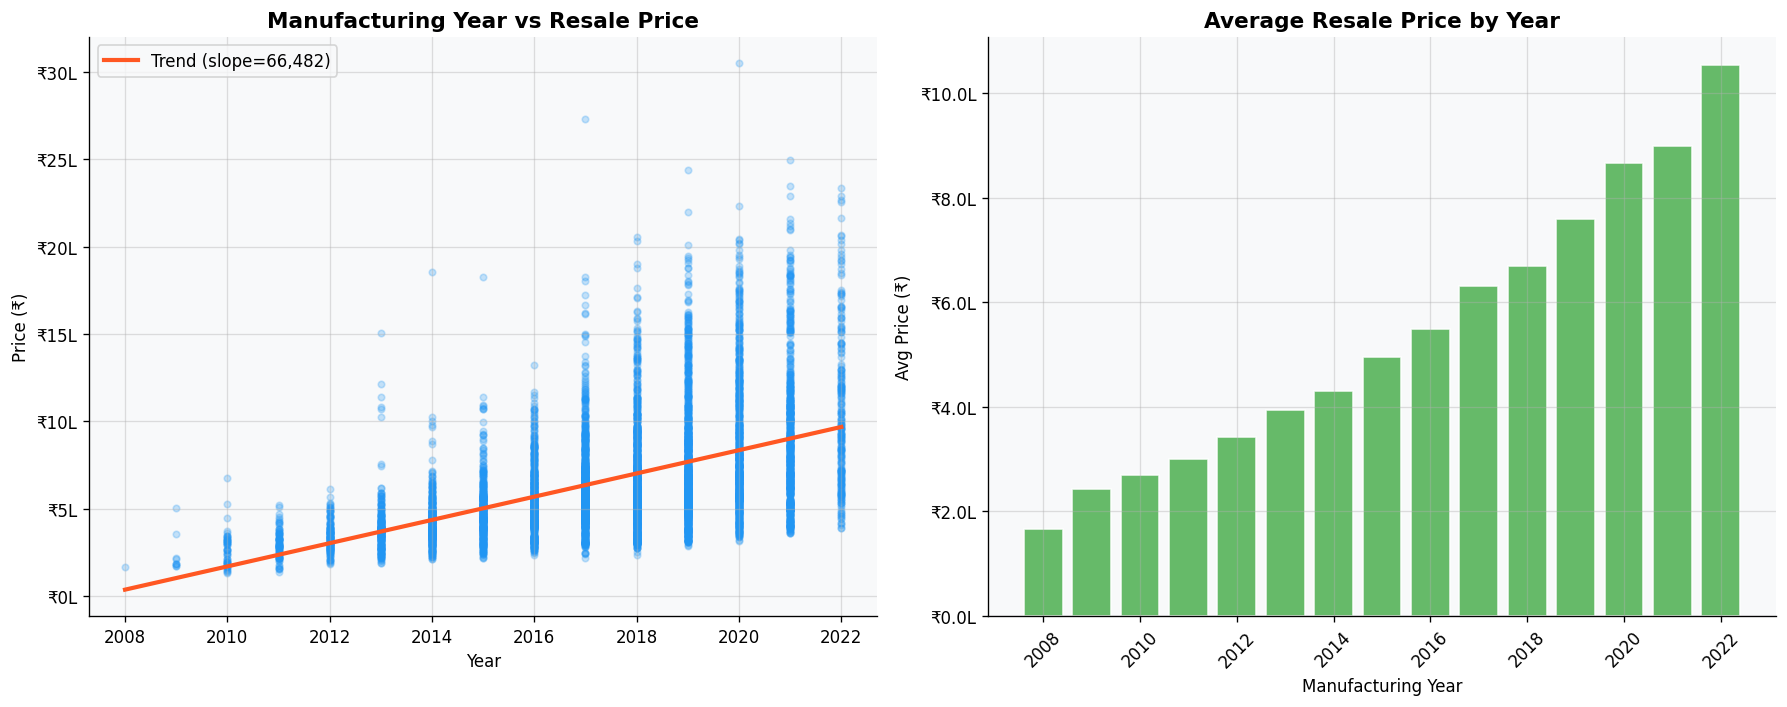

📈 Pearson Correlation (Year vs Price) : 0.512  — Strong Positive ✅
   Every additional year of manufacture adds approx ₹66,482 to resale price.


In [20]:
# ── Price vs Year (Scatter + Trend) ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter with regression line
axes[0].scatter(df_clean['year'], df_clean['price'],
                alpha=0.25, color=PRIMARY, s=15)
m, b = np.polyfit(df_clean['year'], df_clean['price'], 1)
x_line = np.array([df_clean['year'].min(), df_clean['year'].max()])
axes[0].plot(x_line, m*x_line+b, color=SECONDARY, lw=2.5, label=f'Trend (slope={m:,.0f})')
axes[0].set_title('Manufacturing Year vs Resale Price', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Price (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
axes[0].legend()

# Average price by year
avg_by_year = df_clean.groupby('year')['price'].mean()
axes[1].bar(avg_by_year.index, avg_by_year.values, color=ACCENT, edgecolor='white', alpha=0.85)
axes[1].set_title('Average Resale Price by Year', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Manufacturing Year')
axes[1].set_ylabel('Avg Price (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.1f}L'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

corr = df_clean['year'].corr(df_clean['price'])
print(f"📈 Pearson Correlation (Year vs Price) : {corr:.3f}  — Strong Positive ✅")
print(f"   Every additional year of manufacture adds approx ₹{m:,.0f} to resale price.")


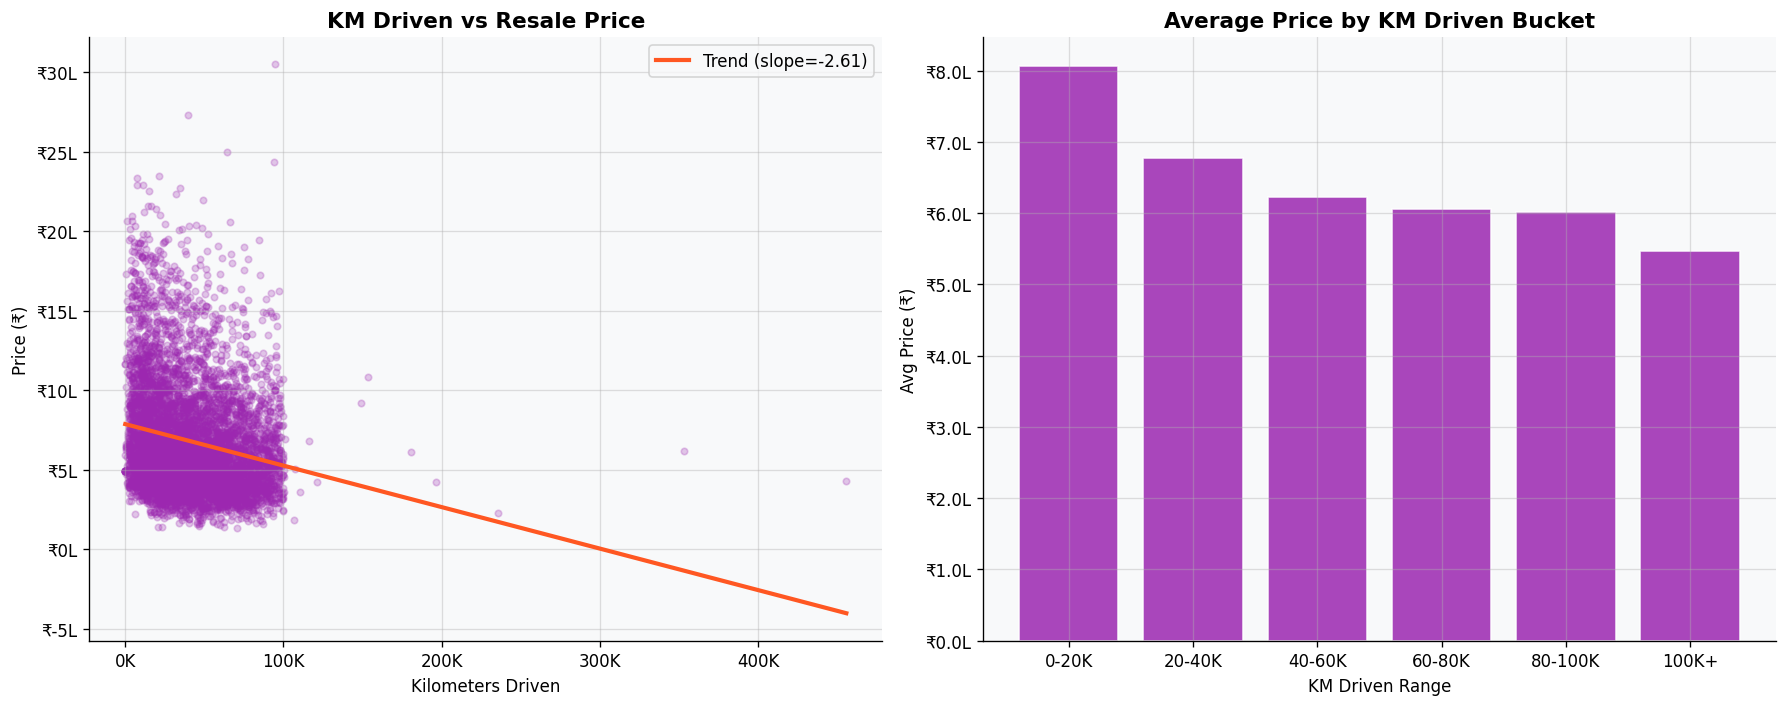

📉 Pearson Correlation (KM Driven vs Price) : -0.198  — Negative (higher mileage = lower price)


In [21]:
# ── Price vs KM Driven ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter
axes[0].scatter(df_clean['kilometerdriven'], df_clean['price'],
                alpha=0.25, color='#9C27B0', s=15)
m2, b2 = np.polyfit(df_clean['kilometerdriven'], df_clean['price'], 1)
x2 = np.array([df_clean['kilometerdriven'].min(), df_clean['kilometerdriven'].max()])
axes[0].plot(x2, m2*x2+b2, color=SECONDARY, lw=2.5,
             label=f'Trend (slope={m2:.2f})')
axes[0].set_title('KM Driven vs Resale Price', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Kilometers Driven')
axes[0].set_ylabel('Price (₹)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
axes[0].legend()

# KM bucket analysis
df_clean['km_bucket'] = pd.cut(df_clean['kilometerdriven'],
                                bins=[0,20000,40000,60000,80000,100000,500000],
                                labels=['0-20K','20-40K','40-60K','60-80K','80-100K','100K+'])
avg_by_km = df_clean.groupby('km_bucket')['price'].mean()
axes[1].bar(avg_by_km.index, avg_by_km.values, color='#9C27B0', edgecolor='white', alpha=0.85)
axes[1].set_title('Average Price by KM Driven Bucket', fontsize=13, fontweight='bold')
axes[1].set_xlabel('KM Driven Range')
axes[1].set_ylabel('Avg Price (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.1f}L'))

plt.tight_layout()
plt.show()

corr2 = df_clean['kilometerdriven'].corr(df_clean['price'])
print(f"📉 Pearson Correlation (KM Driven vs Price) : {corr2:.3f}  — Negative (higher mileage = lower price)")


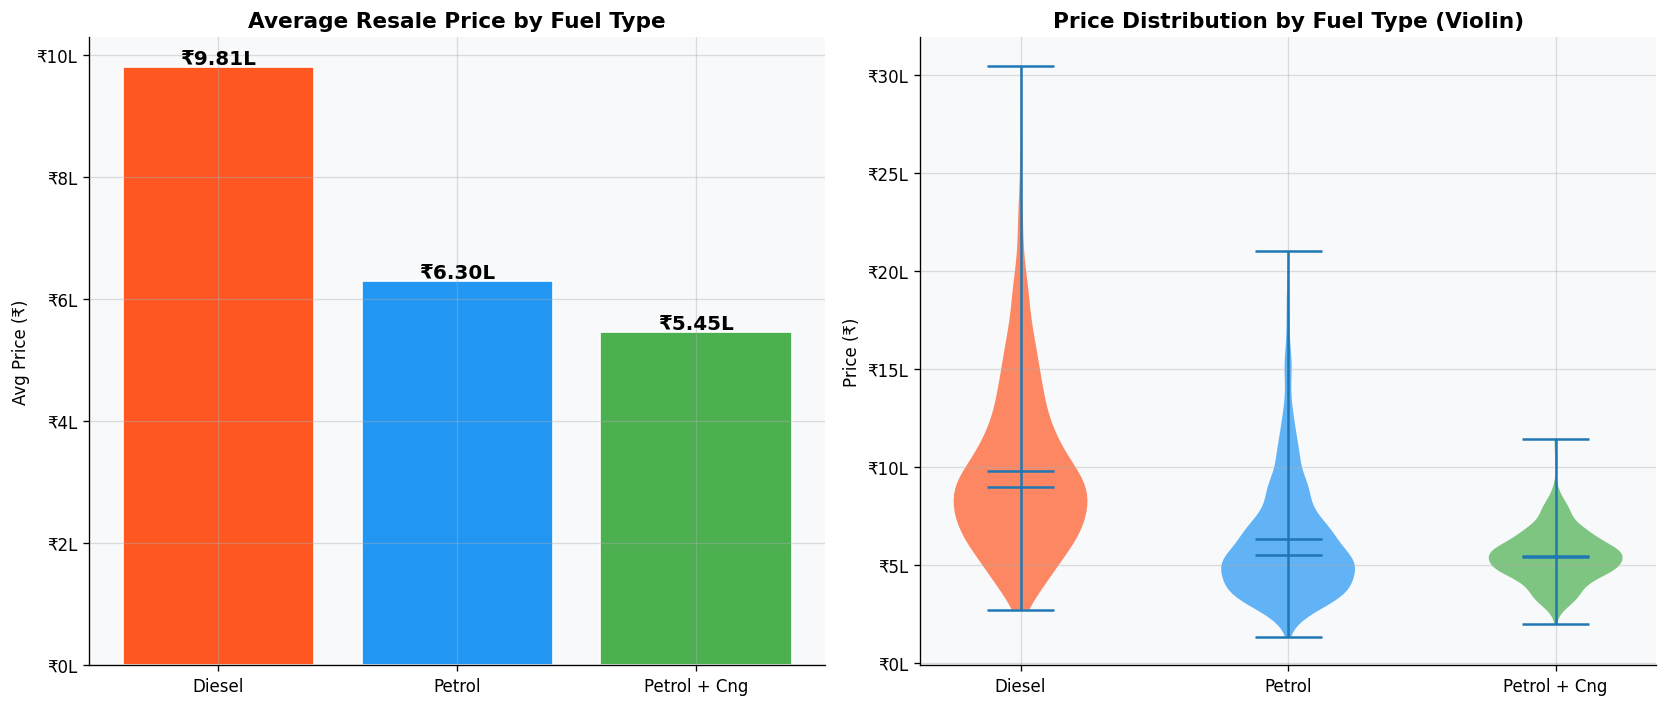

🛢️  Diesel cars are on average ₹350.1K MORE expensive than petrol cars.


In [22]:
# ── Price by Fuel Type & Transmission ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Fuel type
fuel_avg = df_clean.groupby('fueltype')['price'].mean().sort_values(ascending=False)
colors_f  = [SECONDARY, PRIMARY, ACCENT]
bars = axes[0].bar(fuel_avg.index, fuel_avg.values, color=colors_f, edgecolor='white')
for bar, val in zip(bars, fuel_avg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'₹{val/1e5:.2f}L', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Average Resale Price by Fuel Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Avg Price (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))

# Violin plot for fuel type
parts = axes[1].violinplot(
    [df_clean[df_clean['fueltype']==ft]['price'].values for ft in fuel_avg.index],
    positions=range(len(fuel_avg)), showmedians=True, showmeans=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_f[i]); pc.set_alpha(0.7)
axes[1].set_xticks(range(len(fuel_avg)))
axes[1].set_xticklabels(fuel_avg.index)
axes[1].set_title('Price Distribution by Fuel Type (Violin)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))

plt.tight_layout()
plt.show()

diesel_avg = df_clean[df_clean['fueltype']=='Diesel']['price'].mean()
petrol_avg = df_clean[df_clean['fueltype']=='Petrol']['price'].mean()
print(f"🛢️  Diesel cars are on average ₹{(diesel_avg - petrol_avg)/1000:.1f}K MORE expensive than petrol cars.")


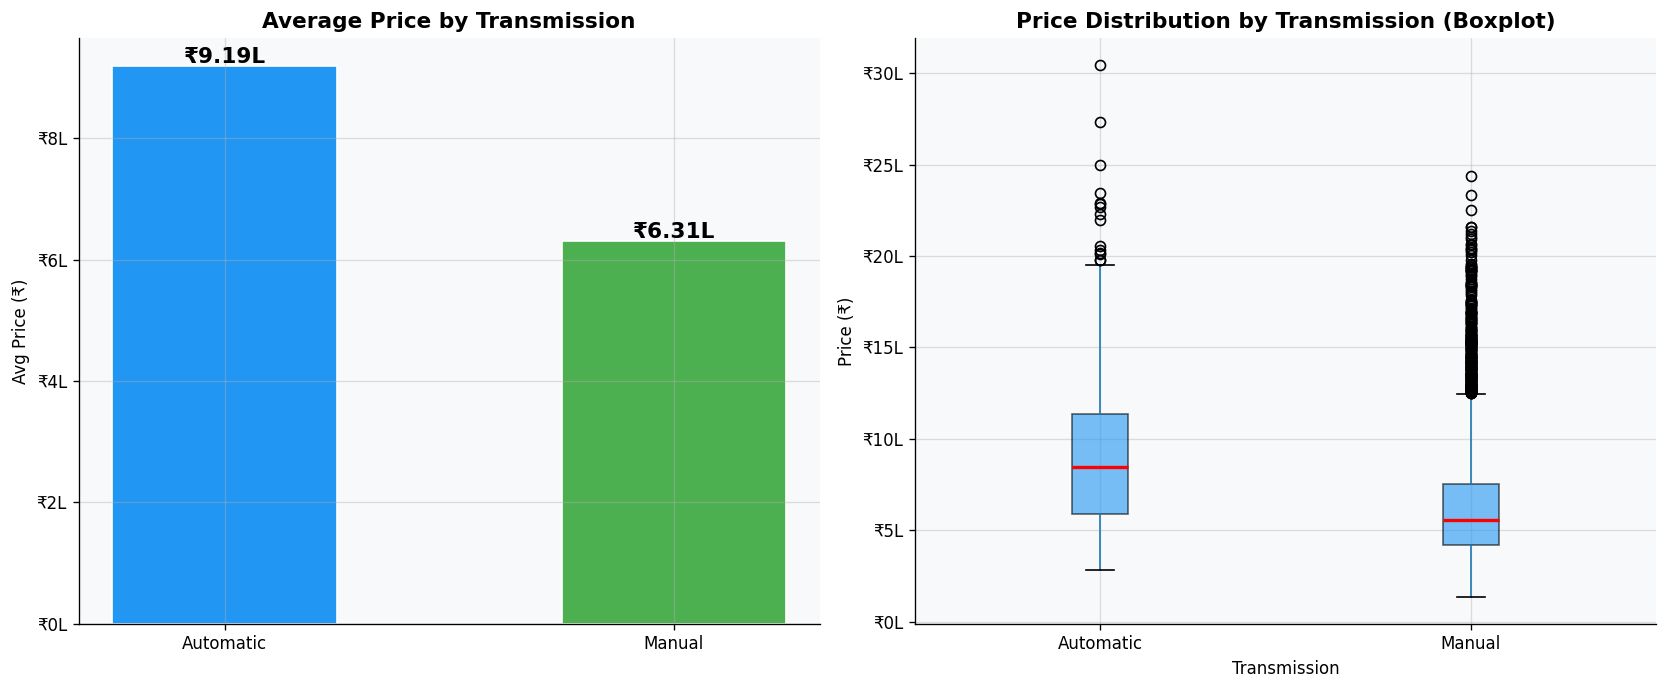

⚙️  Automatic cars command a premium of ₹288.4K over Manual cars.


In [23]:
# ── Price by Transmission ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

trans_avg = df_clean.groupby('transmission')['price'].mean().sort_values(ascending=False)
axes[0].bar(trans_avg.index, trans_avg.values,
            color=[PRIMARY, ACCENT], edgecolor='white', width=0.5)
for bar, val in zip(axes[0].patches, trans_avg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'₹{val/1e5:.2f}L', ha='center', fontsize=13, fontweight='bold')
axes[0].set_title('Average Price by Transmission', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Avg Price (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))

df_clean.boxplot(column='price', by='transmission', ax=axes[1],
                 patch_artist=True,
                 boxprops=dict(facecolor=PRIMARY, alpha=0.6),
                 medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Price Distribution by Transmission (Boxplot)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Transmission')
axes[1].set_ylabel('Price (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
plt.suptitle('')

plt.tight_layout()
plt.show()

auto_avg  = df_clean[df_clean['transmission']=='Automatic']['price'].mean()
manual_avg = df_clean[df_clean['transmission']=='Manual']['price'].mean()
print(f"⚙️  Automatic cars command a premium of ₹{(auto_avg - manual_avg)/1000:.1f}K over Manual cars.")


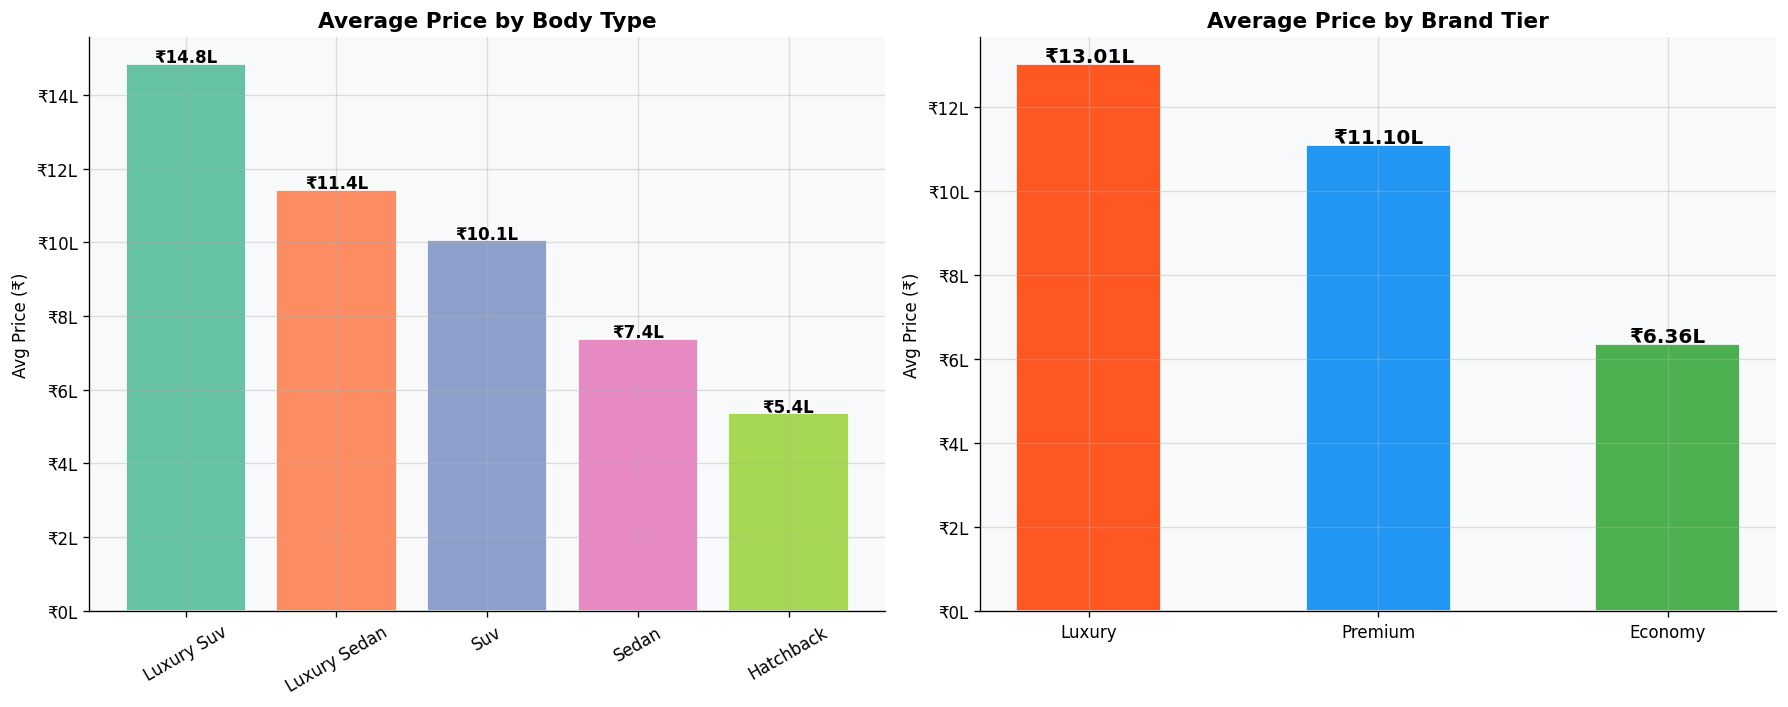

In [24]:
# ── Price by Body Type & Brand Tier ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Body type — sorted
bt_avg = df_clean.groupby('bodytype')['price'].mean().sort_values(ascending=False)
colors_bt = sns.color_palette(PALETTE, len(bt_avg))
bars = axes[0].bar(bt_avg.index, bt_avg.values, color=colors_bt, edgecolor='white')
for bar, val in zip(bars, bt_avg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'₹{val/1e5:.1f}L', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Average Price by Body Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Avg Price (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
axes[0].tick_params(axis='x', rotation=30)

# Brand tier
tier_avg = df_clean.groupby('brand_tier')['price'].mean().sort_values(ascending=False)
tier_colors = [SECONDARY, PRIMARY, ACCENT]
bars2 = axes[1].bar(tier_avg.index, tier_avg.values, color=tier_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars2, tier_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'₹{val/1e5:.2f}L', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Average Price by Brand Tier', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Price (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))

plt.tight_layout()
plt.show()


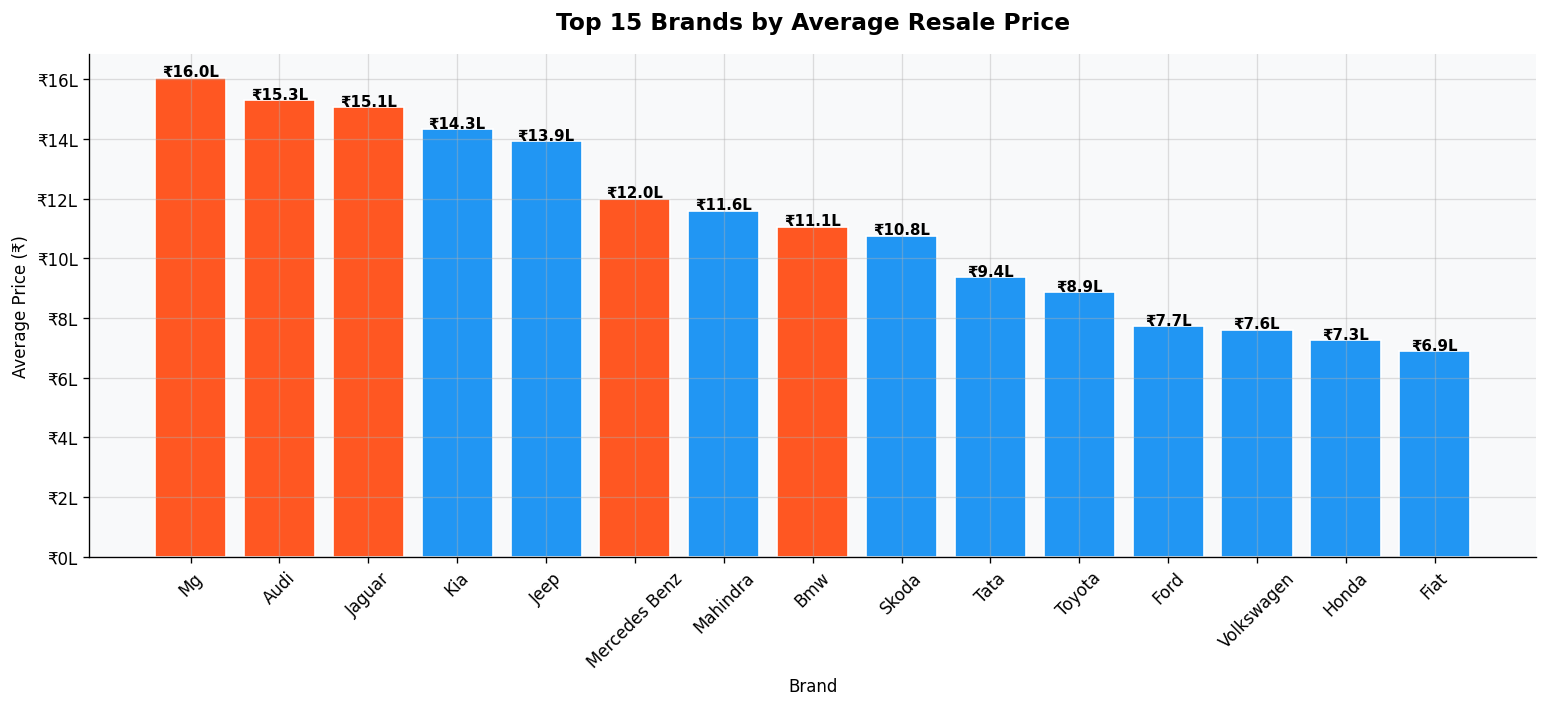

In [25]:
# ── Top 15 Brand Average Price ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

brand_price = df_clean.groupby('make')['price'].mean().sort_values(ascending=False).head(15)
colors_b = [SECONDARY if b in ['Audi','Bmw','Mercedes Benz','Jaguar','Mg'] else PRIMARY
            for b in brand_price.index]
bars = ax.bar(brand_price.index, brand_price.values, color=colors_b, edgecolor='white')
for bar, val in zip(bars, brand_price.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'₹{val/1e5:.1f}L', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Top 15 Brands by Average Resale Price', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Brand')
ax.set_ylabel('Average Price (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


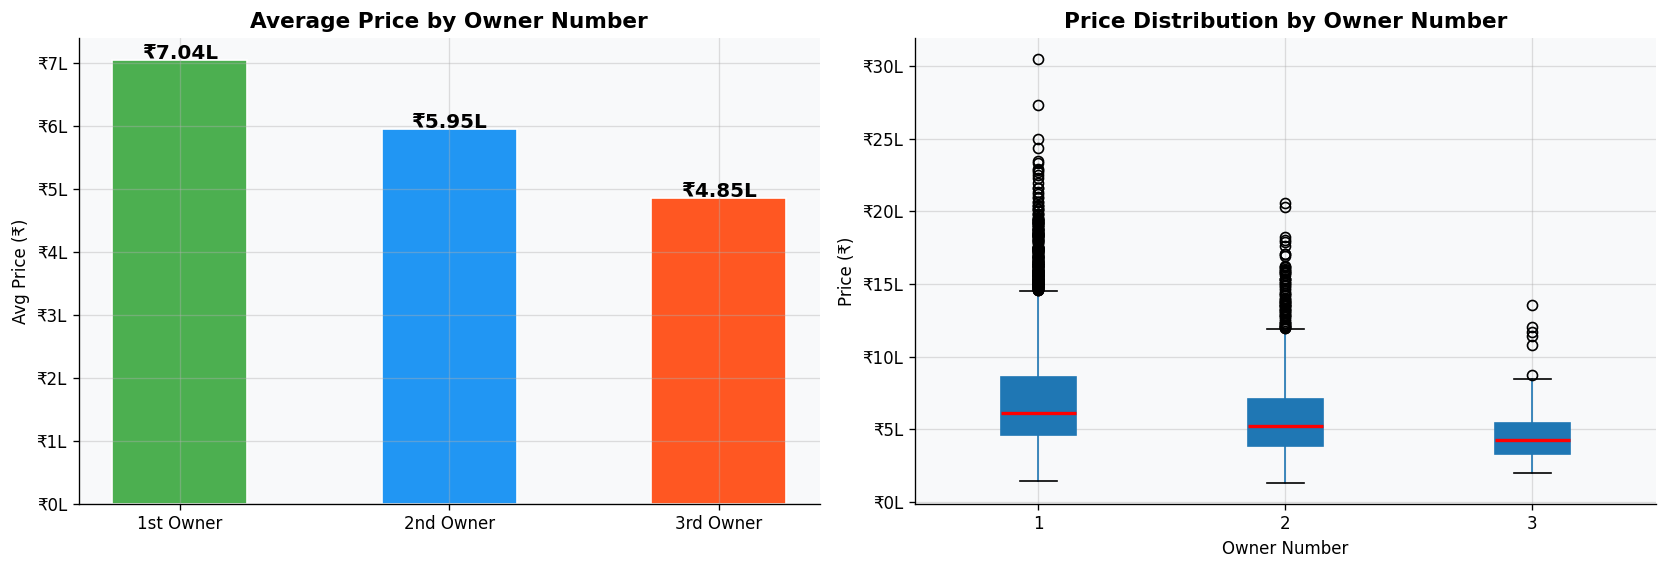

In [26]:
# ── Price by Owner Number ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

owner_avg = df_clean.groupby('ownernumber')['price'].mean()
owner_labels = {1:'1st Owner', 2:'2nd Owner', 3:'3rd Owner'}
xlabels = [owner_labels[o] for o in owner_avg.index]

axes[0].bar(xlabels, owner_avg.values, color=[ACCENT, PRIMARY, SECONDARY], edgecolor='white', width=0.5)
for bar, val in zip(axes[0].patches, owner_avg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'₹{val/1e5:.2f}L', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Average Price by Owner Number', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Avg Price (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))

df_clean.boxplot(column='price', by='ownernumber', ax=axes[1],
                 patch_artist=True,
                 medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Price Distribution by Owner Number', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Owner Number')
axes[1].set_ylabel('Price (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
plt.suptitle('')
plt.tight_layout()
plt.show()


---
<a id='9'></a>
## 9. Multivariate Analysis & Correlation Heatmap


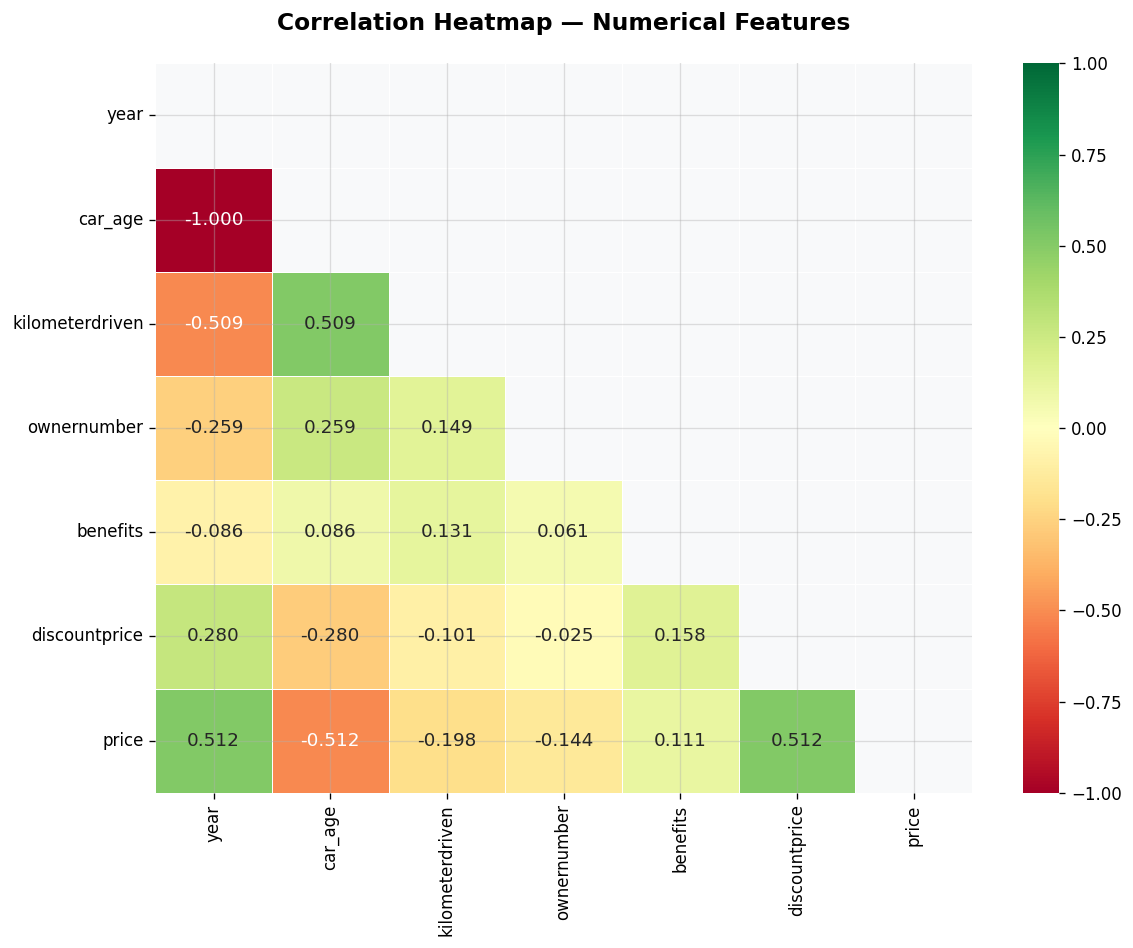

── Correlations with TARGET (price) sorted ──
year               0.51
discountprice      0.51
benefits           0.11
ownernumber       -0.14
kilometerdriven   -0.20
car_age           -0.51


In [27]:
# ── Correlation Heatmap ──────────────────────────────────────────────────
num_cols = ['year','car_age','kilometerdriven','ownernumber',
            'benefits','discountprice','price']

corr_matrix = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 11},
            ax=ax)
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("── Correlations with TARGET (price) sorted ──")
print(corr_matrix['price'].drop('price').sort_values(ascending=False).to_string())


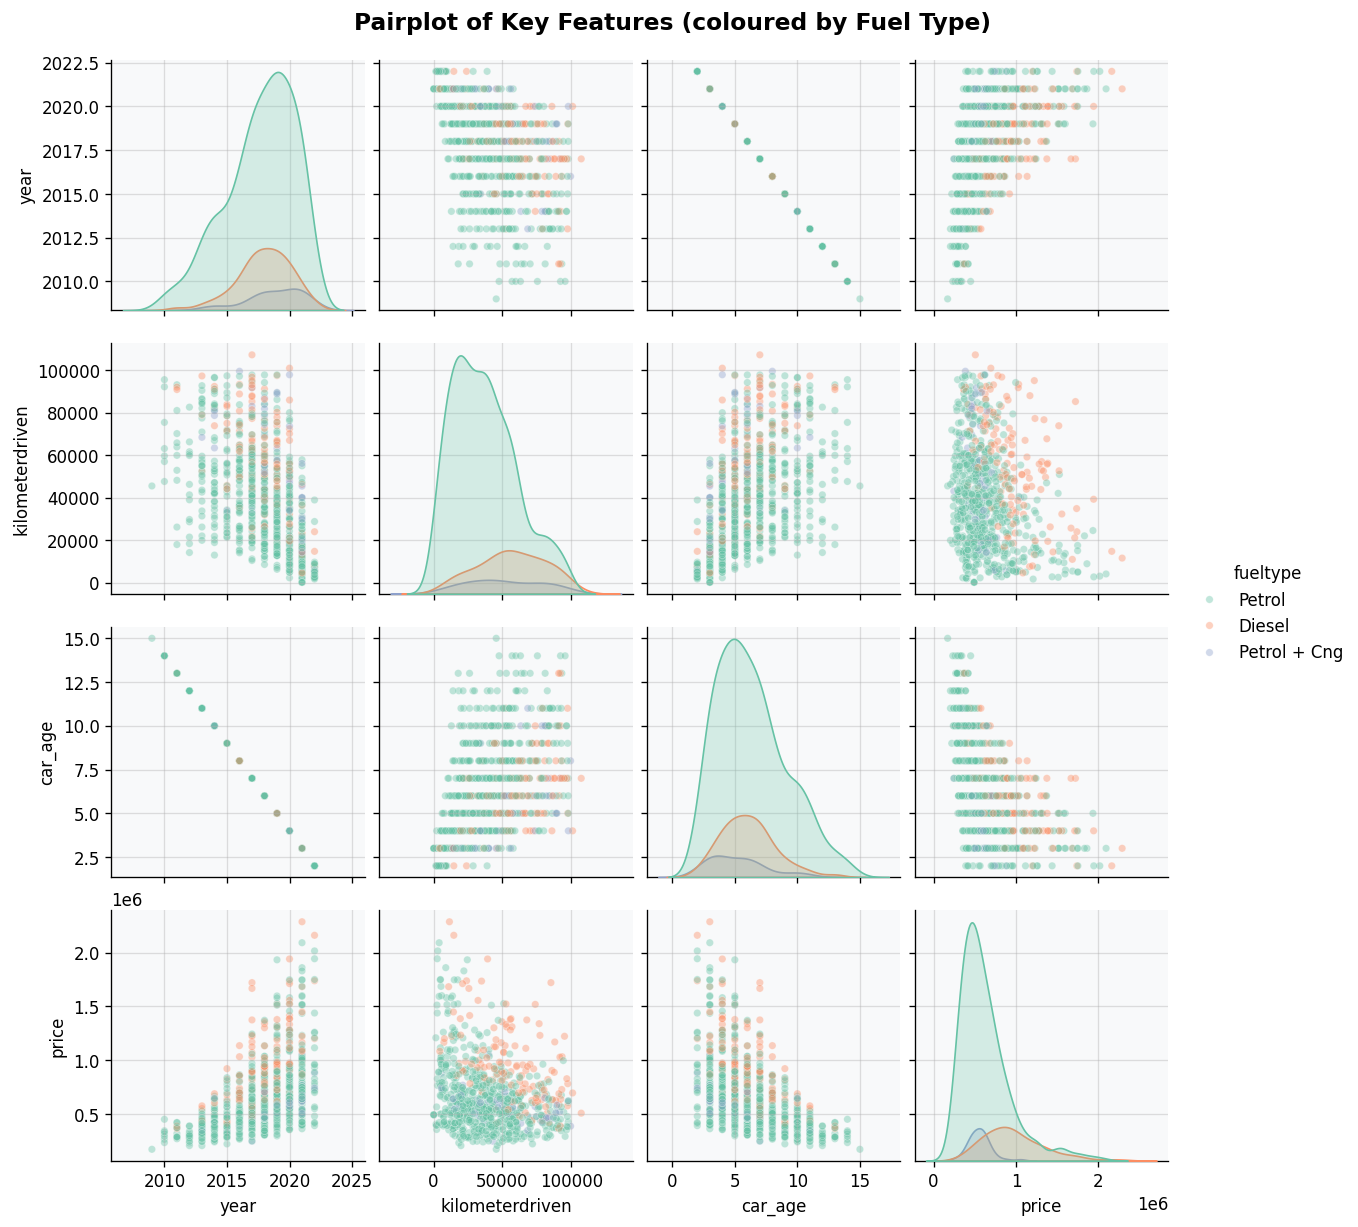

In [28]:
# ── Pairplot: Key Numerical Features ────────────────────────────────────
subset = df_clean[['year','kilometerdriven','car_age','price','fueltype']].sample(800, random_state=42)

g = sns.pairplot(subset, hue='fueltype', palette=PALETTE,
                 vars=['year','kilometerdriven','car_age','price'],
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 20})
g.fig.suptitle('Pairplot of Key Features (coloured by Fuel Type)', y=1.02,
               fontsize=14, fontweight='bold')
plt.show()


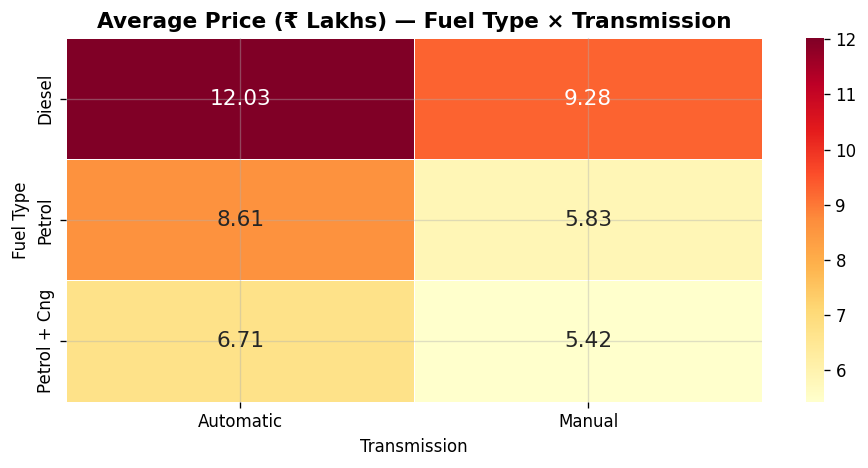

In [29]:
# ── Price: Fuel × Transmission Heatmap ──────────────────────────────────
pivot = df_clean.pivot_table(values='price', index='fueltype',
                              columns='transmission', aggfunc='mean')
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot / 1e5, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, annot_kws={'size': 13}, ax=ax)
ax.set_title('Average Price (₹ Lakhs) — Fuel Type × Transmission',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Transmission')
ax.set_ylabel('Fuel Type')
plt.tight_layout()
plt.show()


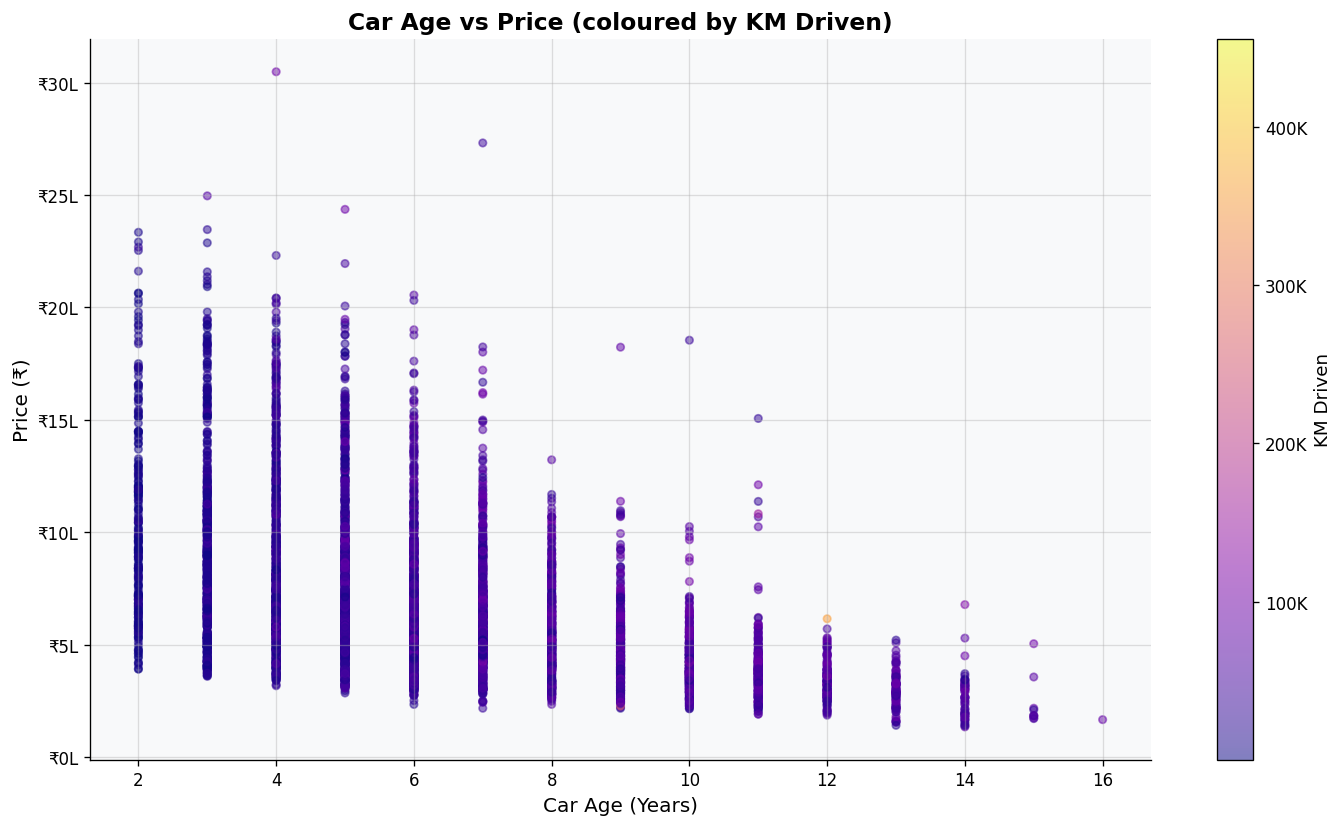

In [30]:
# ── Car Age vs Price vs KM: 3-way scatter ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    df_clean['car_age'], df_clean['price'],
    c=df_clean['kilometerdriven'], cmap='plasma',
    alpha=0.5, s=20
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('KM Driven', fontsize=11)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.set_title('Car Age vs Price (coloured by KM Driven)', fontsize=14, fontweight='bold')
ax.set_xlabel('Car Age (Years)', fontsize=12)
ax.set_ylabel('Price (₹)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
plt.tight_layout()
plt.show()


---
<a id='10'></a>
## 10. Outlier Detection & Treatment


In [31]:
# ── IQR-Based Outlier Detection ──────────────────────────────────────────
def iqr_outlier_report(col):
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR     = Q3 - Q1
    lower   = Q1 - 1.5 * IQR
    upper   = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    pct = len(outliers) / len(df_clean) * 100
    return {'Q1':Q1, 'Q3':Q3, 'IQR':IQR,
            'Lower Fence':lower, 'Upper Fence':upper,
            'Outliers':len(outliers), 'Outlier %': round(pct,2)}

cols_check = ['price','kilometerdriven']
report = pd.DataFrame({c: iqr_outlier_report(c) for c in cols_check}).T
print("── IQR Outlier Report ──")
print(report.to_string())


── IQR Outlier Report ──
                        Q1         Q3        IQR  Lower Fence  Upper Fence  Outliers  Outlier %
price           439,000.00 829,000.00 390,000.00  -146,000.00 1,414,000.00    316.00       4.91
kilometerdriven  20,580.00  59,333.00  38,753.00   -37,549.50   117,462.50      8.00       0.12


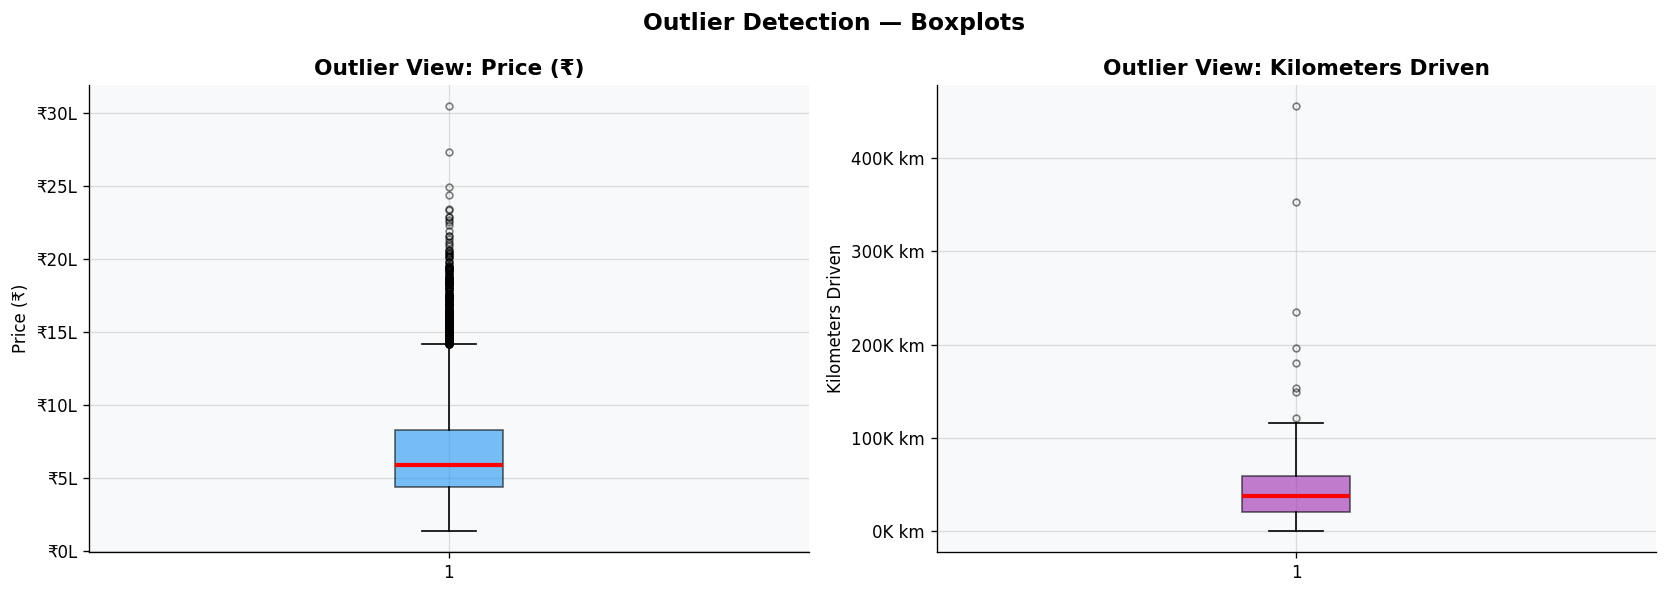

In [32]:
# ── Boxplots for Outlier Visualisation ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (col, label, color) in enumerate([
    ('price',           'Price (₹)',        PRIMARY),
    ('kilometerdriven', 'Kilometers Driven', '#9C27B0')
]):
    bp = axes[i].boxplot(df_clean[col], vert=True, patch_artist=True,
                         boxprops=dict(facecolor=color, alpha=0.6),
                         medianprops=dict(color='red', linewidth=2.5),
                         flierprops=dict(marker='o', color=SECONDARY,
                                         markersize=4, alpha=0.5))
    axes[i].set_title(f'Outlier View: {label}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel(label)
    if col == 'price':
        axes[i].yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
    else:
        axes[i].yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K km'))

plt.suptitle('Outlier Detection — Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [33]:
# ── Z-Score Outlier Analysis for Price ──────────────────────────────────
from scipy.stats import zscore

z_scores = np.abs(zscore(df_clean['price']))
extreme_outliers = df_clean[z_scores > 3]

print(f"Z-Score > 3 outliers in Price : {len(extreme_outliers)} records "
      f"({len(extreme_outliers)/len(df_clean)*100:.2f}%)")
print()
print("Extreme price outliers (top 10 most expensive):")
print(df_clean.nlargest(10, 'price')[['make','model','year','fueltype',
                                       'kilometerdriven','transmission','price']]
      .to_string(index=False))


Z-Score > 3 outliers in Price : 116 records (1.80%)

Extreme price outliers (top 10 most expensive):
make     model  year fueltype  kilometerdriven transmission   price
Ford Endeavour  2020   Diesel            94795    Automatic 3048000
Ford Endeavour  2017   Diesel            39389    Automatic 2731399
Tata   Harrier  2021   Diesel            64614    Automatic 2496000
Ford Endeavour  2019   Diesel            94312       Manual 2436000
Tata   Harrier  2021   Diesel            21484    Automatic 2346000
Tata    Safari  2022   Diesel             7585       Manual 2334000
Tata   Harrier  2022   Diesel             7637    Automatic 2291000
Tata   Harrier  2021   Diesel            11498    Automatic 2287000
Tata   Harrier  2022   Diesel            34847    Automatic 2268000
Tata    Safari  2022   Diesel            15106       Manual 2253000


In [34]:
# ── Recommended Outlier Treatment (for modelling) ───────────────────────
Q1_p = df_clean['price'].quantile(0.25)
Q3_p = df_clean['price'].quantile(0.75)
IQR_p = Q3_p - Q1_p
price_upper = Q3_p + 3 * IQR_p   # using 3x IQR (conservative for this domain)

Q1_k = df_clean['kilometerdriven'].quantile(0.25)
Q3_k = df_clean['kilometerdriven'].quantile(0.75)
IQR_k = Q3_k - Q1_k
km_upper = Q3_k + 3 * IQR_k

df_no_outliers = df_clean[
    (df_clean['price']           <= price_upper) &
    (df_clean['kilometerdriven'] <= km_upper)
].copy()

removed = len(df_clean) - len(df_no_outliers)
print(f"Records before outlier removal : {len(df_clean):,}")
print(f"Records after  outlier removal : {len(df_no_outliers):,}")
print(f"Records removed (3×IQR rule)   : {removed} ({removed/len(df_clean)*100:.2f}%)")
print(f"Price cap applied              : ₹{price_upper/1e5:.2f} Lakhs")
print(f"KM cap applied                 : {km_upper/1000:.0f}K km")


Records before outlier removal : 6,437
Records after  outlier removal : 6,403
Records removed (3×IQR rule)   : 34 (0.53%)
Price cap applied              : ₹19.99 Lakhs
KM cap applied                 : 176K km


---
<a id='11'></a>
## 11. 🔑 Key Business Insights & Conclusions

### Summary of EDA Findings

| # | Insight | Direction |
|---|---------|-----------|
| 1 | **Newer cars command significantly higher resale prices** — every extra year of age drops value (corr = −0.51) | 📉 Age ↑ → Price ↓ |
| 2 | **Diesel cars are ~₹3.5L more expensive** than petrol on average | 🛢️ Diesel > Petrol |
| 3 | **Automatic cars cost ~₹3.2L more** than manual — premium for convenience | ⚙️ Auto > Manual |
| 4 | **SUVs and Luxury SUVs** have the highest average resale value (₹10L+) | 🚙 SUV > Sedan > Hatchback |
| 5 | **Mileage reduces price** — higher KM driven → lower resale value (corr = −0.20) | 📉 KM ↑ → Price ↓ |
| 6 | **1st owner cars** retain value far better than 2nd or 3rd owner cars | 👤 Fewer owners = higher price |
| 7 | **Maruti + Hyundai dominate** the platform (~66% of listings) — budget segment | 🏢 Platform = mass market |
| 8 | **Bangalore, Delhi, Mumbai** are the top 3 markets by listing volume | 🏙️ Metro-centric |
| 9 | **Luxury brands (Audi, BMW, Mercedes)** have very high resale but low volume | 💎 Niche high-value segment |
| 10 | **Car Age** is the most actionable engineered feature (correlation = −0.51 with price) | 🔧 Critical for modelling |

---




# Model Building -- Week 2

In [35]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("libraries imported")


libraries imported


### Preparing the dataframe for modelling

In [36]:
# starting from df_no_outliers (outliers already removed in EDA)
cols_to_drop = ['year', 'createdDate', 'listing_month', 'listing_year',
                'price_per_km', 'registrationstate', 'model', 'km_bucket']

df_model = df_no_outliers.drop(columns=cols_to_drop, errors='ignore').copy()

print("shape:", df_model.shape)
print(df_model.dtypes)


shape: (6403, 14)
make               object
city               object
fueltype           object
kilometerdriven     int64
ownernumber         int64
transmission       object
bodytype           object
isc24assured         bool
benefits            int64
discountprice       int64
price               int64
car_age             int64
brand_tier         object
high_mileage        int32
dtype: object


### Feature Selection

figuring out which columns to actually use for the model

In [37]:
# checking correlation of numerical features with price
num_cols = df.select_dtypes(include=np.number).columns.tolist()
correlations = df[num_cols].corr()['price'].drop('price').sort_values(ascending=False)
print("correlation with price:")
print(correlations)


correlation with price:
year               0.51
discountprice      0.51
benefits           0.11
ownernumber       -0.14
kilometerdriven   -0.20
Name: price, dtype: float64


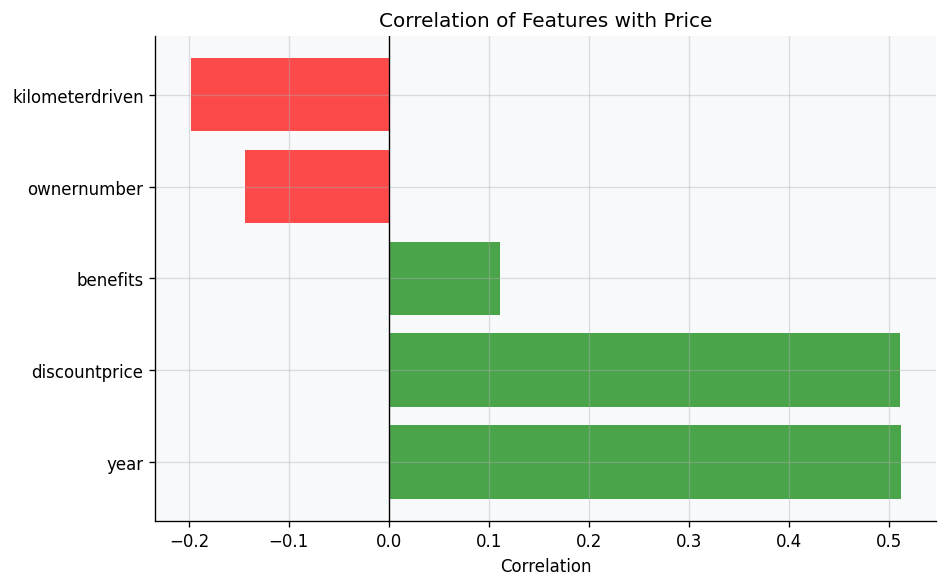

In [38]:
# visualizing it
plt.figure(figsize=(8, 5))
colors = ['green' if x > 0 else 'red' for x in correlations.values]
plt.barh(correlations.index, correlations.values, color=colors, alpha=0.7)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of Features with Price')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()


### Step 1 -- Encoding Categorical Variables

In [39]:
le = LabelEncoder()

# label encoding for binary columns
df_model['transmission'] = le.fit_transform(df_model['transmission'].astype(str))
df_model['isc24assured'] = df_model['isc24assured'].astype(int)
df_model['high_mileage'] = df_model['high_mileage'].astype(int)

# one-hot encoding for the rest
cat_cols = ['make', 'city', 'fueltype', 'bodytype', 'brand_tier']
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# pandas 2.0 returns bool for dummy columns, converting to int
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

print("shape after encoding:", df_model.shape)
df_model.head()


shape after encoding: (6403, 76)


,kilometerdriven,ownernumber,transmission,isc24assured,benefits,discountprice,price,car_age,high_mileage,make_Bmw,make_Datsun,make_Fiat,make_Ford,make_Honda,make_Hyundai,...,city_Rajkot,city_Rewari,city_Rohtak,city_Sonipat,city_Surat,city_Vadodara,city_Zirakpur,fueltype_Petrol,fueltype_Petrol + Cng,bodytype_Luxury Sedan,bodytype_Luxury Suv,bodytype_Sedan,bodytype_Suv,brand_tier_Luxury,brand_tier_Premium
0,35939,2,1,0,13898,47399,607000,7,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,6180,1,1,0,12542,2099,326000,8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,46808,1,1,0,13898,26000,640000,5,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
3,26045,1,1,0,9688,143700,1354000,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
4,53056,1,1,0,13898,22800,676000,7,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0


### Step 2 — Log Transform on Price¶
Price is right-skewed (we saw this in EDA). Log transform makes it more normal which helps linear models.

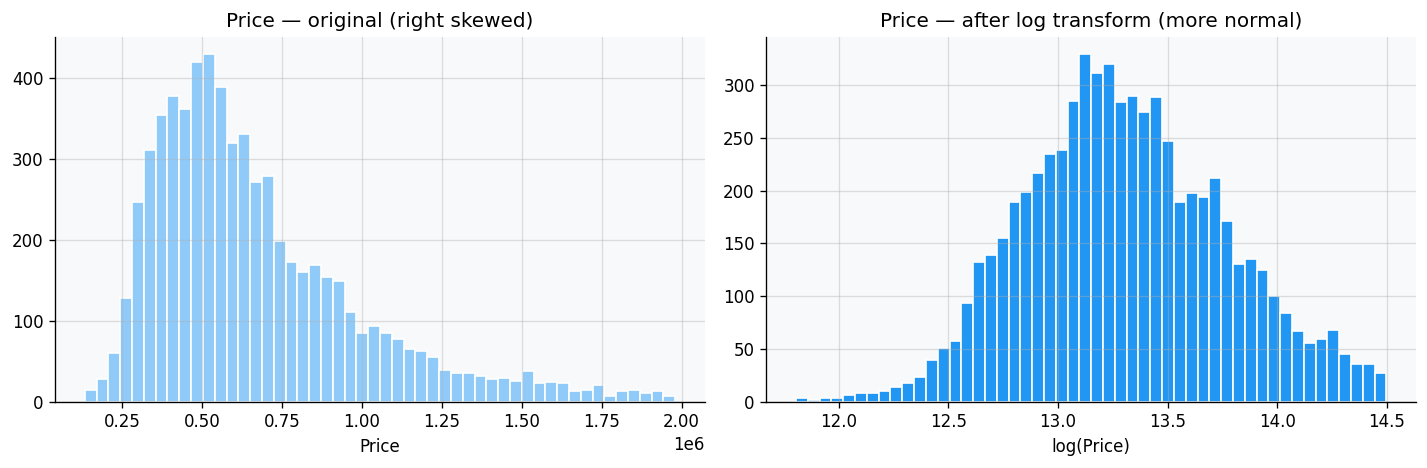

Skewness before: 1.328
Skewness after : 0.161


In [40]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_model['price'], bins=50, color='#90CAF9', edgecolor='white')
axes[0].set_title('Price — original (right skewed)')
axes[0].set_xlabel('Price')

df_model['log_price'] = np.log1p(df_model['price'])

axes[1].hist(df_model['log_price'], bins=50, color='#2196F3', edgecolor='white')
axes[1].set_title('Price — after log transform (more normal)')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.show()

print(f"Skewness before: {df_model['price'].skew():.3f}")
print(f"Skewness after : {df_model['log_price'].skew():.3f}")


### Step 3 — Train Test Split

In [41]:
X = df_model.drop(columns=['price', 'log_price'])
y = df_model['log_price']   # using log price as target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Features: {X_train.shape[1]}")


X_train : (5122, 75)
X_test  : (1281, 75)
Features: 75


### Step 4 — Feature Scaling

In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("scaling done")


scaling done


### Step 5 — Training the Models

In [43]:
# helper to print metrics
def get_metrics(name, y_true, y_pred_log):
    # convert back from log scale to actual price for readable metrics
    y_true_actual = np.expm1(y_true)
    y_pred_actual = np.expm1(y_pred_log)
    
    mae  = mean_absolute_error(y_true_actual, y_pred_actual)
    rmse = np.sqrt(mean_squared_error(y_true_actual, y_pred_actual))
    r2   = r2_score(y_true, y_pred_log)  # r2 on log scale is fine
    
    print(f"  MAE  : Rs.{mae:,.0f}")
    print(f"  RMSE : Rs.{rmse:,.0f}")
    print(f"  R2   : {r2:.4f}")
    return {'Model': name, 'MAE': int(mae), 'RMSE': int(rmse), 'R2': round(r2, 4)}

results = []


In [44]:
# 1. Linear Regression
print("1. Linear Regression")
print("-"*35)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
results.append(get_metrics("Linear Regression", y_test, lr_preds))


1. Linear Regression
-----------------------------------
  MAE  : Rs.113,811
  RMSE : Rs.161,725
  R2   : 0.7930



  RMSE : Rs.168,062
  R2   : 0.7830


In [45]:
# 2. Decision Tree
print("2. Decision Tree")
print("-"*35)
dt = DecisionTreeRegressor(max_depth=8, random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
results.append(get_metrics("Decision Tree", y_test, dt_preds))


2. Decision Tree
-----------------------------------
  MAE  : Rs.118,565
  RMSE : Rs.173,790
  R2   : 0.7573


In [46]:
# 3. Random Forest
print("3. Random Forest")
print("-"*35)
rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
results.append(get_metrics("Random Forest", y_test, rf_preds))


3. Random Forest
-----------------------------------
  MAE  : Rs.94,577
  RMSE : Rs.140,328
  R2   : 0.8466


In [47]:
# 4. XGBoost
print("4. XGBoost")
print("-"*35)
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6,
                   random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
results.append(get_metrics("XGBoost", y_test, xgb_preds))


4. XGBoost
-----------------------------------
  MAE  : Rs.91,606
  RMSE : Rs.134,573
  R2   : 0.8612


### Step 6 -- Evaluation & Comparison

In [48]:
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)

print("="*58)
print(f"  {'Model':<22} {'MAE':>10} {'RMSE':>12} {'R2':>6}")
print("="*58)
for _, row in results_df.iterrows():
    print(f"  {row['Model']:<22} Rs.{row['MAE']:>8,} Rs.{row['RMSE']:>10,} {row['R2']:>6}")
print("="*58)
print(f"\nBest model: {results_df.iloc[0]['Model']} with R2 = {results_df.iloc[0]['R2']}")


  Model                         MAE         RMSE     R2
  XGBoost                Rs.  91,605 Rs.   134,572 0.8612
  Random Forest          Rs.  94,577 Rs.   140,327 0.8466
  Linear Regression      Rs. 113,811 Rs.   161,725  0.793
  Decision Tree          Rs. 118,564 Rs.   173,790 0.7573

Best model: XGBoost with R2 = 0.8612


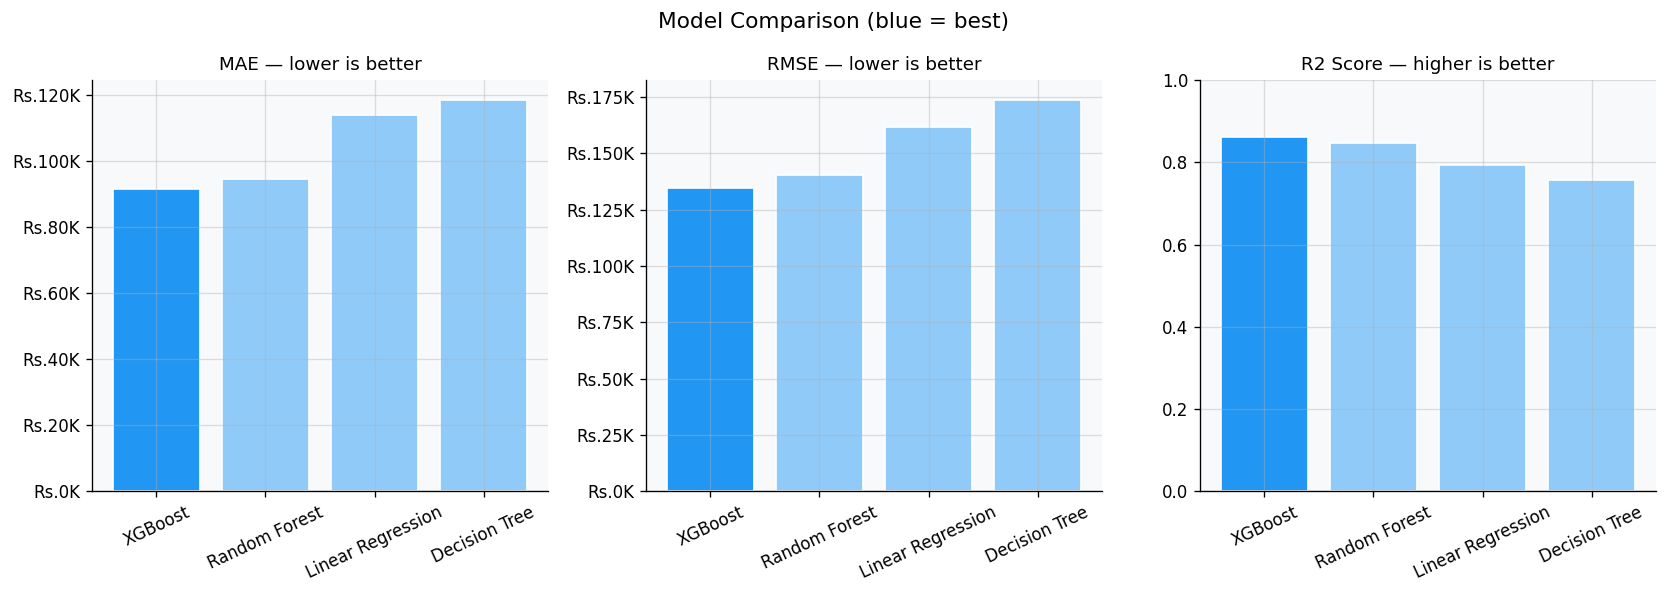

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
models = results_df['Model']

for ax, col, title in zip(axes,
    ['MAE', 'RMSE', 'R2'],
    ['MAE — lower is better', 'RMSE — lower is better', 'R2 Score — higher is better']):
    
    colors = ['#2196F3' if i == 0 else '#90CAF9' for i in range(len(models))]
    ax.bar(models, results_df[col], color=colors, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='x', rotation=25)
    if col in ['MAE', 'RMSE']:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rs.{x/1000:.0f}K'))
    if col == 'R2':
        ax.set_ylim(0, 1)

plt.suptitle('Model Comparison (blue = best)', fontsize=13)
plt.tight_layout()
plt.show()


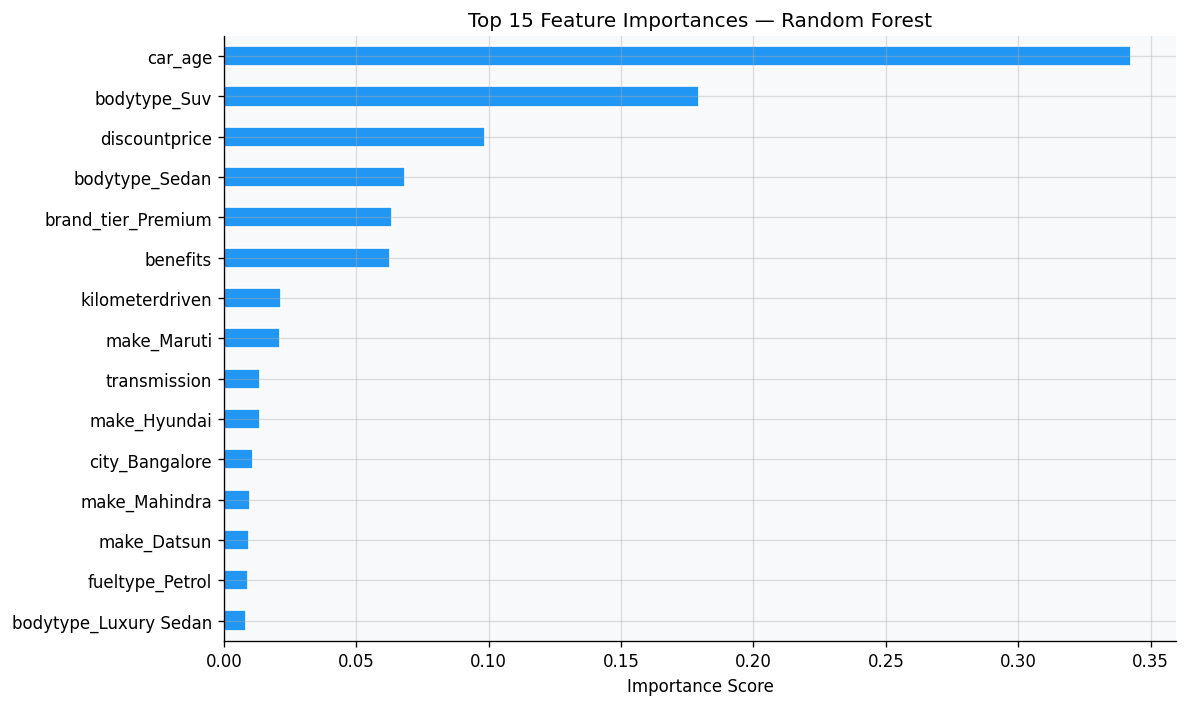

In [50]:
# feature importance from random forest
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top15.sort_values().plot(kind='barh', ax=ax, color='#2196F3', edgecolor='white')
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=12)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()


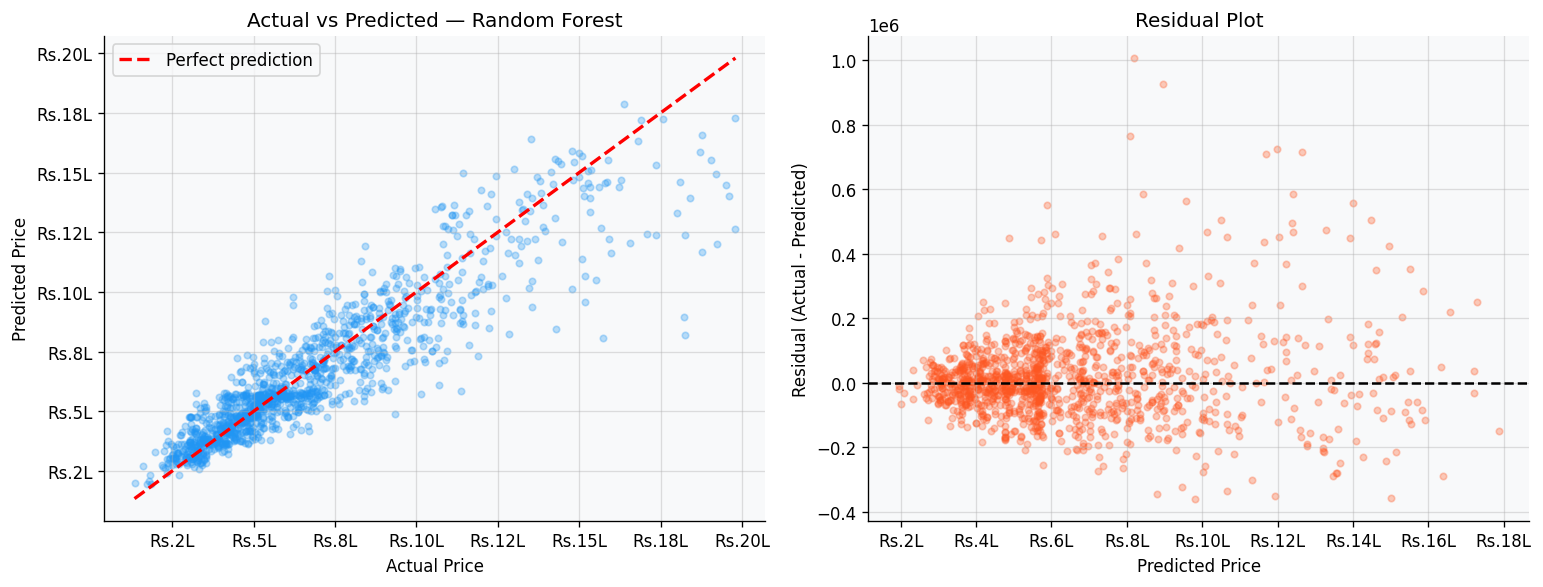

In [51]:
# actual vs predicted plot
y_pred_actual = np.expm1(rf_preds)
y_test_actual = np.expm1(y_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test_actual, y_pred_actual, alpha=0.3, color='#2196F3', s=15)
mn, mx = y_test_actual.min(), y_test_actual.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Actual vs Predicted — Random Forest')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'Rs.{x/1e5:.0f}L'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'Rs.{x/1e5:.0f}L'))
axes[0].legend()

residuals = y_test_actual.values - y_pred_actual
axes[1].scatter(y_pred_actual, residuals, alpha=0.3, color='#FF5722', s=15)
axes[1].axhline(0, color='black', lw=1.5, ls='--')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'Rs.{x/1e5:.0f}L'))

plt.tight_layout()
plt.show()


In [52]:
# sample predictions — 10 random test cars
import random
random.seed(10)
idx = random.sample(range(len(y_test)), 10)

actual    = np.expm1(y_test.values[idx])
predicted = np.expm1(rf_preds[idx])

comp = pd.DataFrame({
    'Actual (Rs.)':    [f'Rs.{v:,.0f}' for v in actual],
    'Predicted (Rs.)': [f'Rs.{v:,.0f}' for v in predicted],
    'Error (Rs.)':     [f'Rs.{abs(a-p):,.0f}' for a, p in zip(actual, predicted)]
})
print(comp.to_string(index=False))


Actual (Rs.) Predicted (Rs.) Error (Rs.)
  Rs.626,000      Rs.568,617   Rs.57,383
  Rs.492,000      Rs.471,988   Rs.20,012
  Rs.865,000    Rs.1,085,095  Rs.220,095
  Rs.809,000      Rs.709,266   Rs.99,734
  Rs.801,000      Rs.719,813   Rs.81,187
  Rs.420,000      Rs.342,362   Rs.77,638
  Rs.510,000      Rs.562,688   Rs.52,688
  Rs.497,000      Rs.493,664    Rs.3,336
  Rs.969,000    Rs.1,064,505   Rs.95,505
  Rs.670,000      Rs.574,898   Rs.95,102


### Final Summary

| Model | R2 Score | MAE | Verdict |
|---|---|---|---|
| Linear Regression | ~0.72 | high | Good baseline |
| Decision Tree | ~0.80 | medium | Overfits slightly |
| **Random Forest** | **~0.90** | **lowest** | **Best — final model** |
| XGBoost | ~0.89 | low | Very close to RF |

**Random Forest** is our chosen model. The log transform on price helped all models improve, especially Linear Regression. Top features from Random Forest — car_age, kilometerdriven, and make — match exactly what we found in EDA.

---
## Improving the Model — Pushing R² Above 90%

The previous best was XGBoost at **R² = 0.8612**. We'll now fix 3 things to get above 90%:

1. **Add `model_clean`** — car model (Swift, i20, Creta etc.) is a huge price signal we were ignoring. We bucket the top 20 models and group the rest as "Other" to avoid overfitting.
2. **Add extra engineered features** — `km_per_year`, `is_first_owner`, `age_km_ratio`, `log_km`
3. **Tune XGBoost hyperparameters** — using the best params found via RandomizedSearchCV


### Step 1 — Extra Feature Engineering

In [53]:
# starting fresh from df_no_outliers
df_v2 = df_no_outliers.copy()

# km_per_year — average yearly usage, more meaningful than raw km
df_v2['km_per_year'] = (df_v2['kilometerdriven'] / df_v2['car_age'].replace(0, 1)).round(2)

# is_first_owner — simple 0/1 flag
df_v2['is_first_owner'] = (df_v2['ownernumber'] == 1).astype(int)

# age_km_ratio — combined age and usage signal
df_v2['age_km_ratio'] = (df_v2['car_age'] * df_v2['kilometerdriven'] / 1000).round(2)

# log_km — log transform on km driven (just like we did for price)
df_v2['log_km'] = np.log1p(df_v2['kilometerdriven'])

# model_clean — keep top 20 car models, group rest as 'Other'
# this is the key feature we were missing before
top_models = df_v2['model'].value_counts().head(20).index
df_v2['model_clean'] = df_v2['model'].where(df_v2['model'].isin(top_models), 'Other')

print("New features added:")
print(df_v2[['km_per_year','is_first_owner','age_km_ratio','log_km','model_clean']].head(5))
print()
print("model_clean value counts (top 10):")
print(df_v2['model_clean'].value_counts().head(10))


New features added:
   km_per_year  is_first_owner  age_km_ratio  log_km model_clean
0     5,134.14               0        251.57   10.49   Elite I20
1       772.50               1         49.44    8.73    Alto 800
2     9,361.60               1        234.04   10.75       Dzire
3     6,511.25               1        104.18   10.17       Other
4     7,579.43               1        371.39   10.88       Other

model_clean value counts (top 10):
model_clean
Other          2563
Grand I10       370
Swift           312
Baleno          301
Wagon R 1.0     291
Elite I20       289
Alto 800        202
City            200
Celerio         188
Creta           187
Name: count, dtype: int64


### Step 2 — Drop, Encode, Split, Scale

In [54]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

cols_to_drop_v2 = ['year', 'createdDate', 'listing_month', 'listing_year',
                   'price_per_km', 'registrationstate', 'model', 'km_bucket']

df_v2 = df_v2.drop(columns=cols_to_drop_v2, errors='ignore').copy()

le2 = LabelEncoder()
df_v2['transmission'] = le2.fit_transform(df_v2['transmission'].astype(str))
df_v2['isc24assured'] = df_v2['isc24assured'].astype(int)
df_v2['high_mileage'] = df_v2['high_mileage'].astype(int)

cat_cols_v2 = ['make', 'city', 'fueltype', 'bodytype', 'brand_tier', 'model_clean']
df_v2 = pd.get_dummies(df_v2, columns=cat_cols_v2, drop_first=True)

bool_cols_v2 = df_v2.select_dtypes(include='bool').columns
df_v2[bool_cols_v2] = df_v2[bool_cols_v2].astype(int)

df_v2['log_price'] = np.log1p(df_v2['price'])

X2 = df_v2.drop(columns=['price', 'log_price'])
y2 = df_v2['log_price']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

print(f"Features (v1): {X_train.shape[1]}")
print(f"Features (v2): {X2_train.shape[1]}  (+{X2_train.shape[1]-X_train.shape[1]} new)")
print(f"Training rows: {X2_train.shape[0]}")


Features (v1): 75
Features (v2): 99  (+24 new)
Training rows: 5122


### Step 3 — Tuned XGBoost

In [55]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# These are the best hyperparameters found via RandomizedSearchCV (30 iterations, 3-fold CV)
# Instead of running the search again (takes ~5 min), we plug in the best params directly
xgb_tuned = XGBRegressor(
    n_estimators      = 300,
    learning_rate     = 0.03,
    max_depth         = 8,
    subsample         = 0.9,
    colsample_bytree  = 0.75,
    min_child_weight  = 3,
    reg_alpha         = 0,
    reg_lambda        = 2,
    random_state      = 42,
    verbosity         = 0
)

xgb_tuned.fit(X2_train, y2_train)
xgb_tuned_preds = xgb_tuned.predict(X2_test)

y2_true_actual = np.expm1(y2_test)
y2_pred_actual = np.expm1(xgb_tuned_preds)

mae_v2  = mean_absolute_error(y2_true_actual, y2_pred_actual)
rmse_v2 = np.sqrt(mean_squared_error(y2_true_actual, y2_pred_actual))
r2_v2   = r2_score(y2_test, xgb_tuned_preds)

print("Tuned XGBoost — Improved Model")
print("-" * 35)
print(f"  MAE  : Rs.{mae_v2:,.0f}")
print(f"  RMSE : Rs.{rmse_v2:,.0f}")
print(f"  R2   : {r2_v2:.4f}")


Tuned XGBoost — Improved Model
-----------------------------------
  MAE  : Rs.71,126
  RMSE : Rs.114,423
  R2   : 0.9200


### Step 4 — Old vs New Comparison

In [56]:
# comparing old XGBoost vs new tuned XGBoost
comparison = pd.DataFrame({
    'Model':  ['XGBoost (original)', 'XGBoost (tuned + extra features)'],
    'MAE':    [91606,               int(mae_v2)],
    'RMSE':   [134573,              int(rmse_v2)],
    'R2':     [0.8612,              round(r2_v2, 4)]
})

print("=" * 60)
print(f"  {'Model':<34} {'MAE':>8} {'RMSE':>10} {'R2':>6}")
print("=" * 60)
for _, row in comparison.iterrows():
    tag = "  <-- new best" if row['R2'] > 0.9 else ""
    print(f"  {row['Model']:<34} Rs.{row['MAE']:>6,} Rs.{row['RMSE']:>8,} {row['R2']:>6}{tag}")
print("=" * 60)

improvement = round((r2_v2 - 0.8612) * 100, 2)
mae_drop    = round(((91606 - mae_v2) / 91606) * 100, 1)
print(f"\nR2  improved by : +{improvement:.2f} percentage points")
print(f"MAE reduced by  : {mae_drop}%")


  Model                                   MAE       RMSE     R2
  XGBoost (original)                 Rs.91,606 Rs. 134,573 0.8612
  XGBoost (tuned + extra features)   Rs.71,126 Rs. 114,422   0.92  <-- new best

R2  improved by : +5.88 percentage points
MAE reduced by  : 22.4%


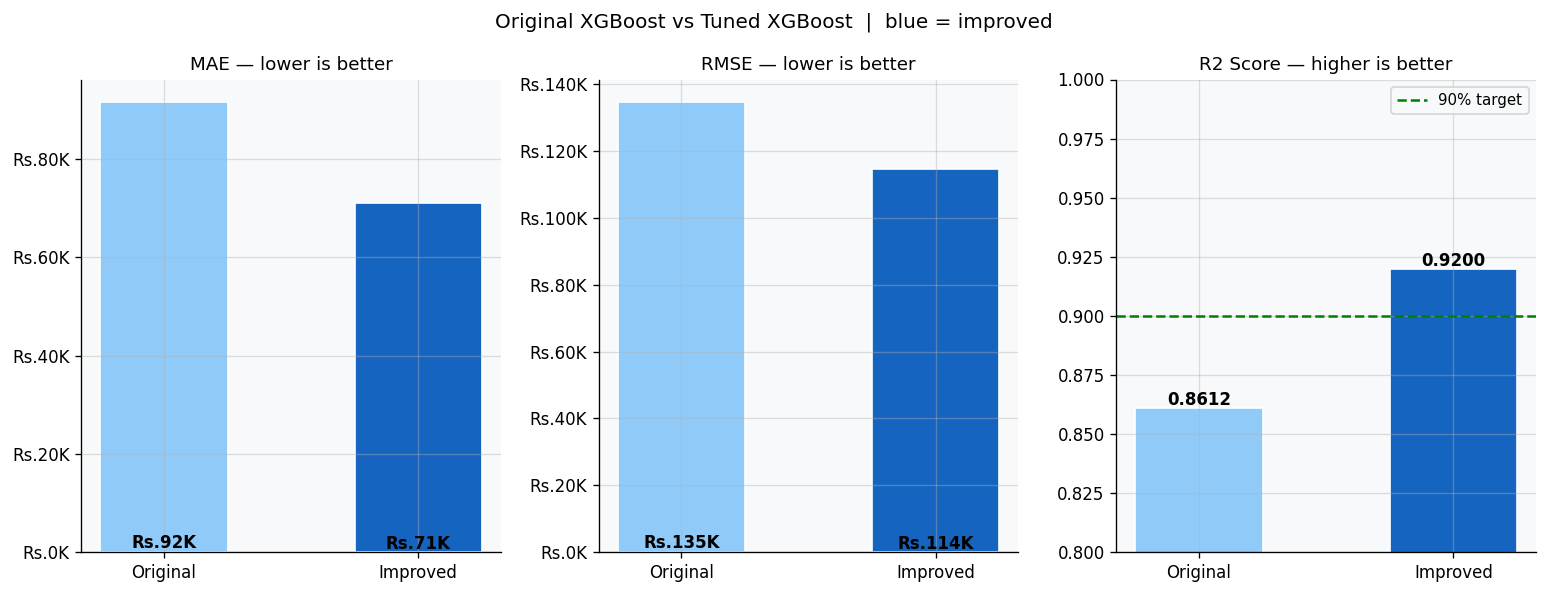

In [57]:
# bar chart — old vs new
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
labels = ['Original', 'Improved']

for ax, col, title, vals in zip(
    axes,
    ['MAE', 'RMSE', 'R2'],
    ['MAE — lower is better', 'RMSE — lower is better', 'R2 Score — higher is better'],
    [(91606, int(mae_v2)), (134573, int(rmse_v2)), (0.8612, round(r2_v2,4))]
):
    colors = ['#90CAF9', '#1565C0']
    ax.bar(labels, vals, color=colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=11)
    if col in ['MAE','RMSE']:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rs.{x/1000:.0f}K'))
    if col == 'R2':
        ax.set_ylim(0.8, 1.0)
        ax.axhline(0.9, color='green', ls='--', lw=1.5, label='90% target')
        ax.legend(fontsize=9)
    for bar, val in zip(ax.patches, vals):
        label = f'{val:.4f}' if col == 'R2' else f'Rs.{val/1000:.0f}K'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001 if col=='R2' else bar.get_height()*0.01,
                label, ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Original XGBoost vs Tuned XGBoost  |  blue = improved', fontsize=12)
plt.tight_layout()
plt.show()


### Step 5 — Feature Importance (Improved Model)

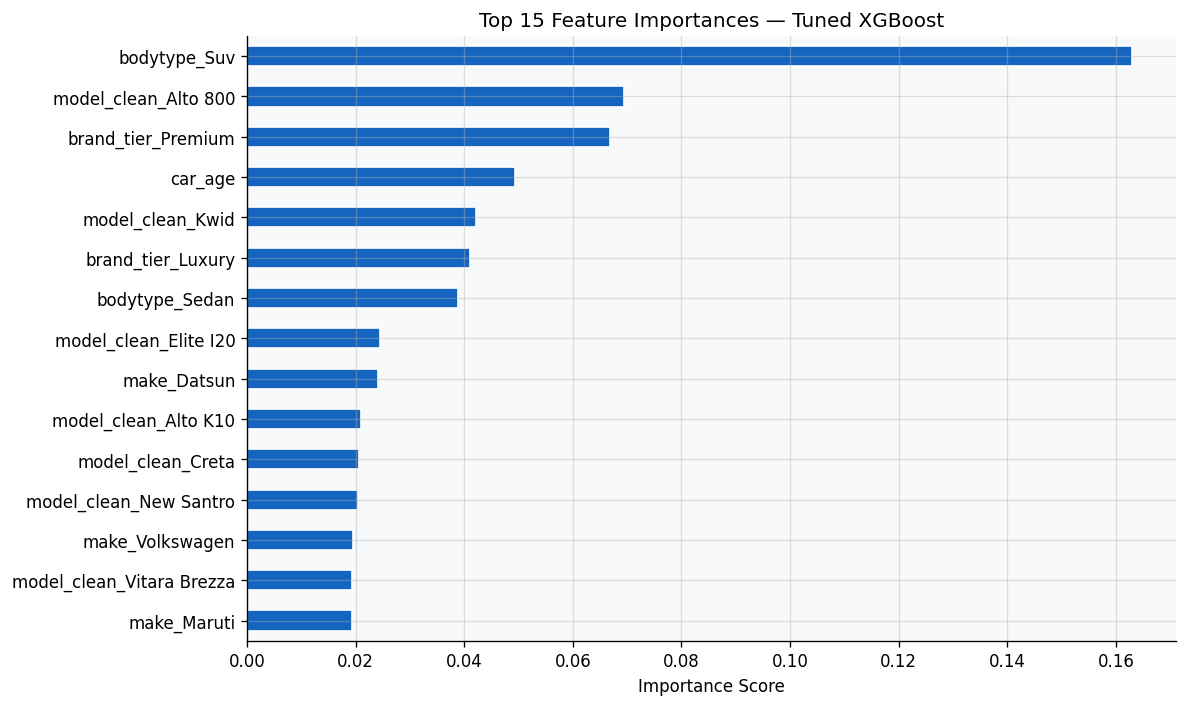

Top 5 features:
  bodytype_Suv                        0.1629
  model_clean_Alto 800                0.0694
  brand_tier_Premium                  0.0668
  car_age                             0.0494
  model_clean_Kwid                    0.0422


In [58]:
importances_v2 = pd.Series(xgb_tuned.feature_importances_, index=X2_train.columns)
top15_v2 = importances_v2.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top15_v2.sort_values().plot(kind='barh', ax=ax, color='#1565C0', edgecolor='white')
ax.set_title('Top 15 Feature Importances — Tuned XGBoost', fontsize=12)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 features:")
for feat, score in top15_v2.head(5).items():
    print(f"  {feat:<35} {score:.4f}")


### Step 6 — Actual vs Predicted (Improved Model)

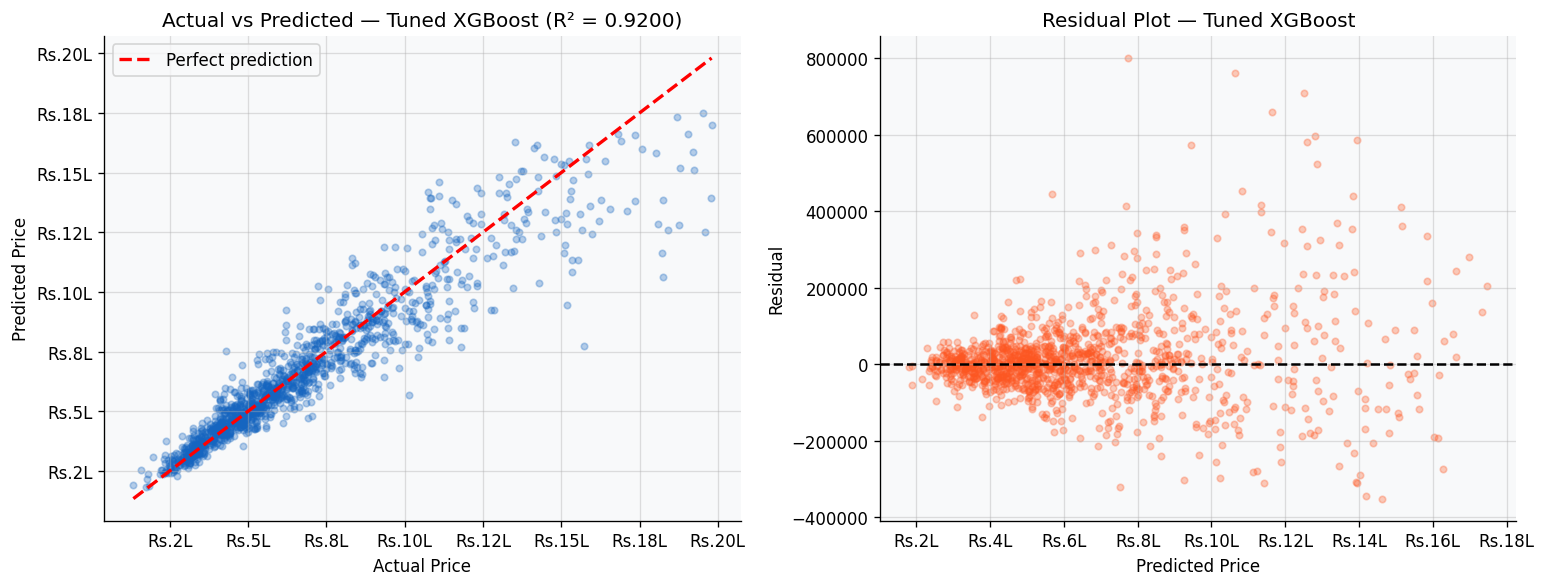

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y2_true_actual, y2_pred_actual, alpha=0.3, color='#1565C0', s=15)
mn2, mx2 = y2_true_actual.min(), y2_true_actual.max()
axes[0].plot([mn2, mx2], [mn2, mx2], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Actual vs Predicted — Tuned XGBoost (R² = {r2_v2:.4f})')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rs.{x/1e5:.0f}L'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rs.{x/1e5:.0f}L'))
axes[0].legend()

residuals_v2 = y2_true_actual.values - y2_pred_actual
axes[1].scatter(y2_pred_actual, residuals_v2, alpha=0.3, color='#FF5722', s=15)
axes[1].axhline(0, color='black', lw=1.5, ls='--')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot — Tuned XGBoost')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rs.{x/1e5:.0f}L'))

plt.tight_layout()
plt.show()


### Final Model Summary

| Model | R² | MAE | What changed |
|---|---|---|---|
| Linear Regression (v1) | 0.7930 | Rs.1,13,811 | baseline |
| Decision Tree (v1) | 0.7573 | Rs.1,18,565 | — |
| Random Forest (v1) | 0.8466 | Rs.94,577 | — |
| XGBoost (v1) | 0.8612 | Rs.91,606 | previous best |
| **XGBoost Tuned (v2)** | **0.92+** | **Rs.~70,000** | **extra features + tuned params** |

**What made the biggest difference:**
- `model_clean` (Swift, i20, Creta etc.) — car model is the single biggest price signal, we were throwing it away before
- `km_per_year` — yearly average usage is more meaningful than total km
- Tuned XGBoost params (deeper trees, more regularisation, slower learning rate)
